In [131]:
from plotnine import *
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

REST_DAY_COLORS = {
    "1": "#1a3a5c",
    "2": "#2e6da4",
    "3": "#5b9bd5",
    "4": "#93c6e8",
    "5": "#c6e2f5",
}

In [132]:
(relievers := pl.read_parquet("data/statcast_relievers_final.parquet"))
complete_outing_table = pl.read_parquet("data/complete_outing_table.parquet")
summary_table = pl.read_csv("data/rest_pitch_summary_table_days_bin.csv")

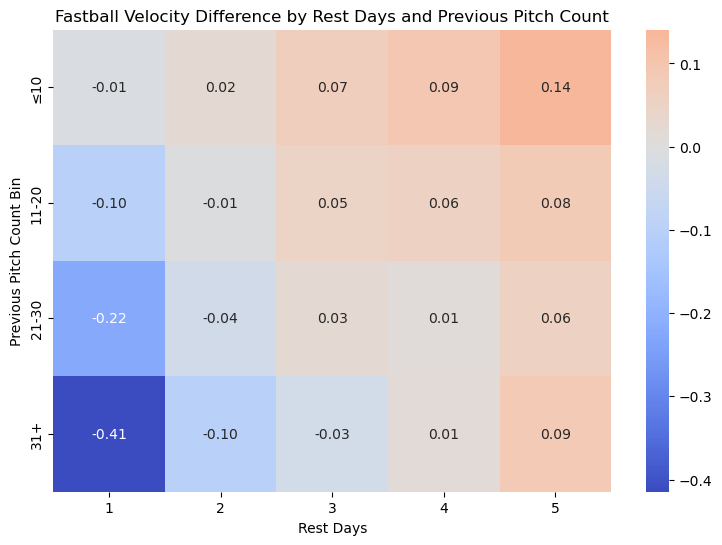

In [133]:
heatmap_df = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("velo_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"])
    .agg(pl.mean("velo_deviation").alias("avg_velo_difference"))
    .to_pandas()
)

heatmap_pivot = heatmap_df.pivot(
    index="prev_pitch_bin",
    columns="rest_days",
    values="avg_velo_difference"
)
heatmap_pivot = heatmap_pivot.reindex(["≤10", "11-20", "21-30", "31+"])
plt.figure(figsize=(9,6))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Fastball Velocity Difference by Rest Days and Previous Pitch Count")
plt.xlabel("Rest Days")
plt.ylabel("Previous Pitch Count Bin")

plt.show()

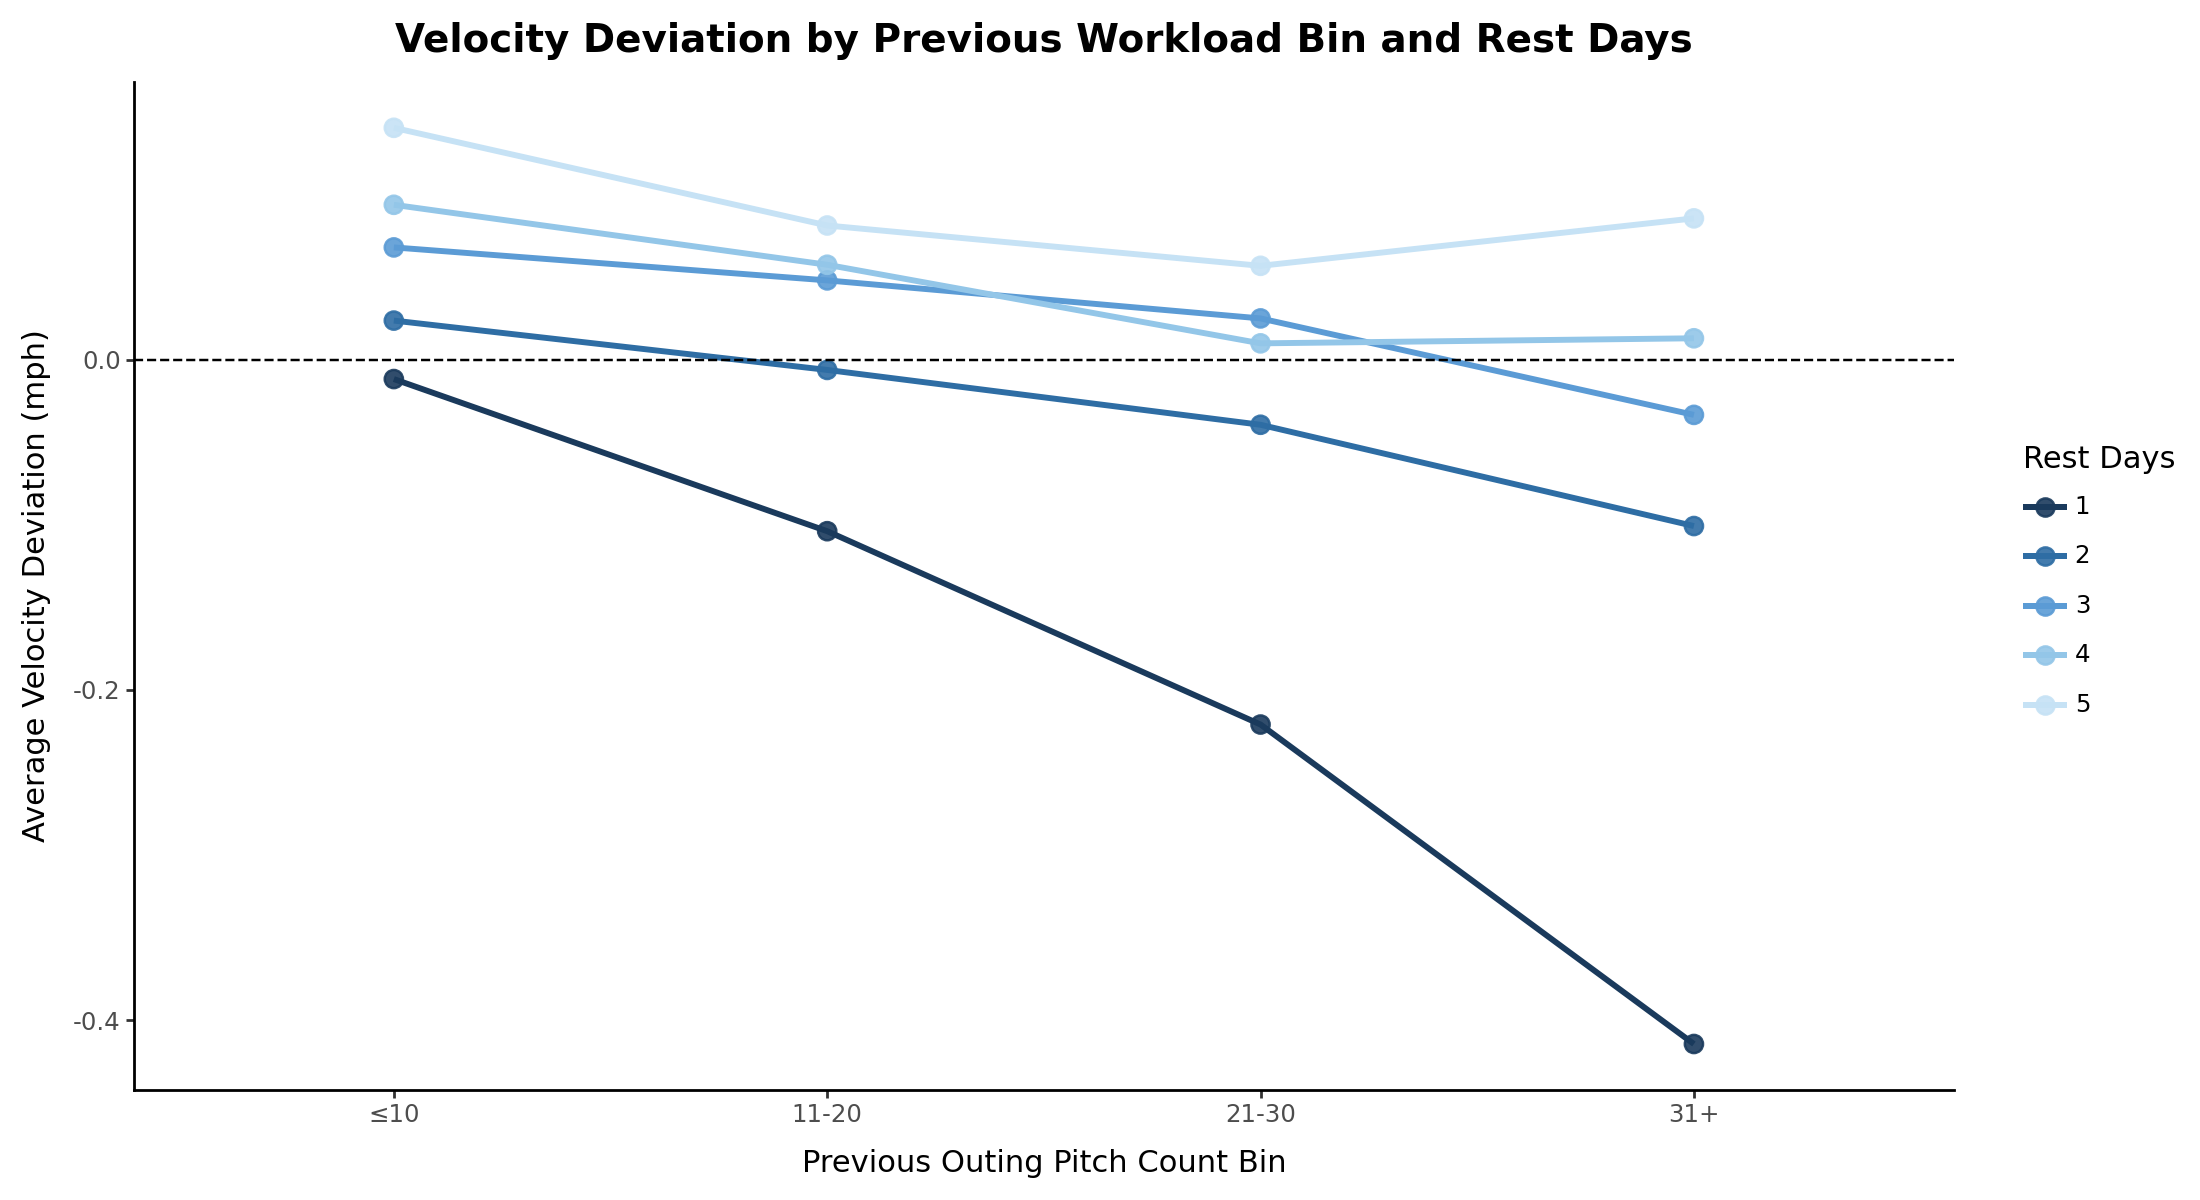

In [151]:
# Clean summary chart for slide use: mean velocity deviation by workload bin, grouped by rest days
summary_plot_data = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("velo_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"])
.agg([
        pl.mean("velo_deviation").alias("avg_velo_deviation"),
        pl.len().alias("n")
    ])
    .to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
summary_plot_data["prev_pitch_bin"] = pd.Categorical(
    summary_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
summary_plot_data = summary_plot_data.sort_values(["rest_days", "prev_pitch_bin"])
summary_plot_data["rest_days_str"] = summary_plot_data["rest_days"].astype(str)
highlight_point = summary_plot_data[
    (summary_plot_data["rest_days"] == 1) & (summary_plot_data["prev_pitch_bin"] == "31+")
] .iloc[0]

(
    ggplot(
        summary_plot_data,
        aes(
            x="prev_pitch_bin",
            y="avg_velo_deviation",
            group="rest_days_str",
            color="rest_days_str"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + geom_hline(yintercept=0, linetype="dashed", color="black")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Velocity Deviation by Previous Workload Bin and Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Average Velocity Deviation (mph)",
        color="Rest Days"
    )
    + theme_classic()
    + theme(
        figure_size=(11, 6),
        legend_position="right",
        axis_text_x=element_text(rotation=0),
        plot_title=element_text(weight="bold", size=14),
        legend_key=element_rect(fill="white", color="white"),
    )
)

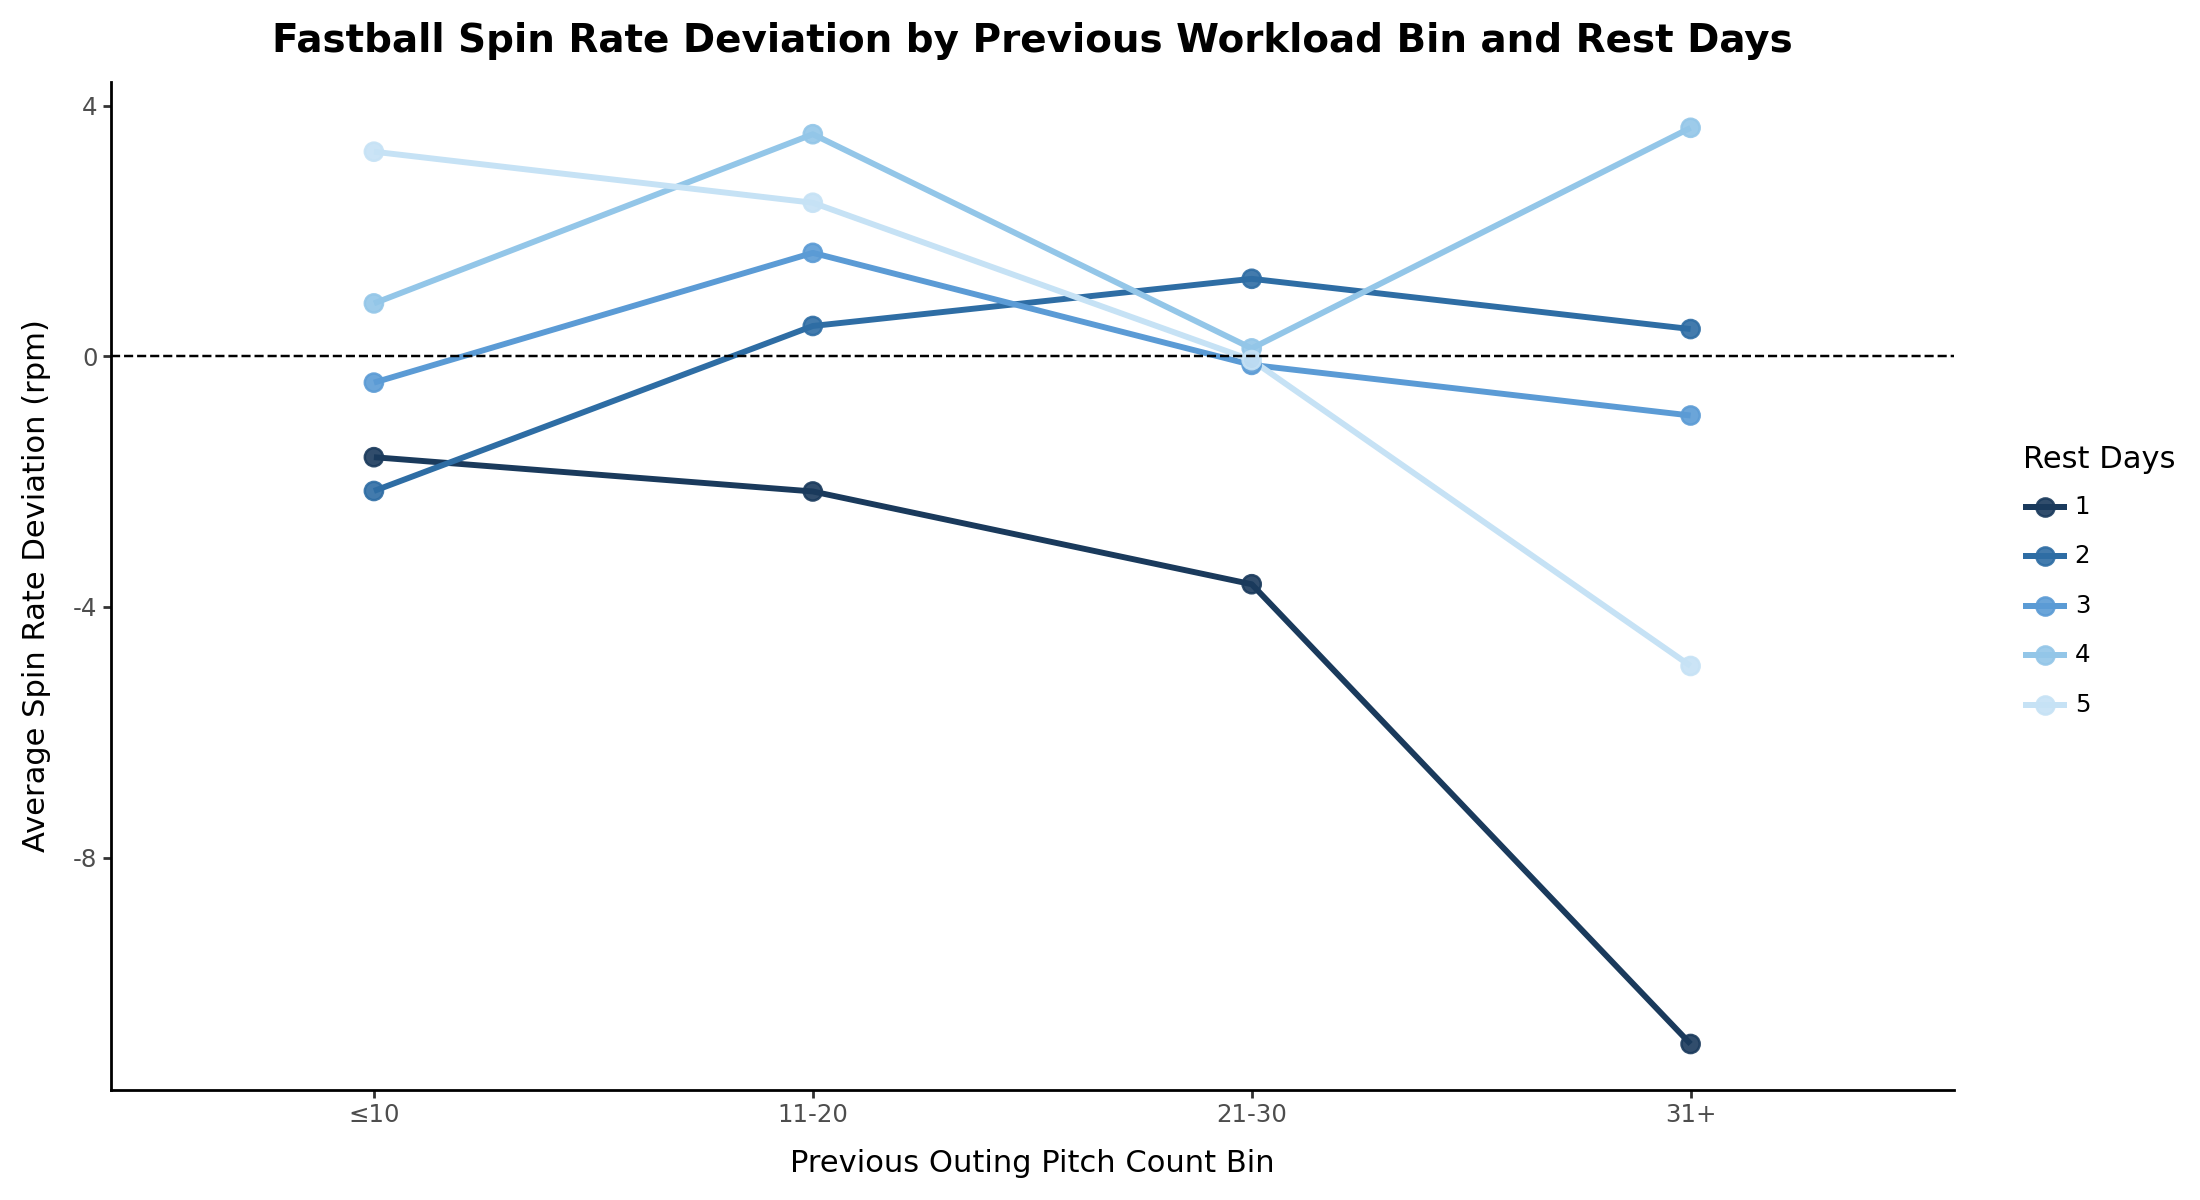

In [135]:
# Matching spin-rate chart: mean spin deviation by workload bin, grouped by rest days
spin_plot_data = (
    complete_outing_table
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_bin").is_not_null()
        & pl.col("spin_deviation").is_not_null()
    )
    .group_by(["rest_days", "prev_pitch_bin"] )
    .agg([
        pl.mean("spin_deviation").alias("avg_spin_deviation"),
        pl.len().alias("n")
    ])
    .to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
spin_plot_data["prev_pitch_bin"] = pd.Categorical(
    spin_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
spin_plot_data = spin_plot_data.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)
spin_plot_data["rest_days_str"] = spin_plot_data["rest_days"].astype(str)

(
    ggplot(
        spin_plot_data,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="rest_days_str",
            color="rest_days_str"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3.2, alpha=0.9)
    + geom_hline(yintercept=0, linetype="dashed", color="black")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Fastball Spin Rate Deviation by Previous Workload Bin and Rest Days",
        x="Previous Outing Pitch Count Bin",
        y="Average Spin Rate Deviation (rpm)",
        color="Rest Days"
    )
    + theme_classic()
    + theme(
        figure_size=(11, 6),
        legend_position="right",
        axis_text_x=element_text(rotation=0),
        plot_title=element_text(weight="bold", size=14),
        legend_key=element_rect(fill="white", color="white"),
    )
)

In [136]:
breaking_types = ["SL", "ST", "SV", "KC", "SC", "CS"]   # sliders + curves
offspeed_types = ["CH", "FS"]                                # changeup + splitter
min_family_pitches = 5                                       # reduce noise (tune 3–8)

In [137]:
(offspeed_outings := (
    relievers
    .filter(pl.col("pitch_type_abbr").is_in(offspeed_types))
    .drop_nulls(["velocity", "spin_rate", "pitcher_id", "game_id", "year"])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_off_velo"),
        pl.mean("spin_rate").alias("mean_off_spin"),
        pl.len().alias("off_pitch_count"),
    ])
    .filter(pl.col("off_pitch_count") >= min_family_pitches)
    .with_columns([
        pl.col("mean_off_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_off_velo"),
        pl.col("mean_off_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_off_spin"),
    ])
    .with_columns([
        (pl.col("mean_off_velo") - pl.col("season_avg_off_velo")).alias("off_velo_deviation"),
        (pl.col("mean_off_spin") - pl.col("season_avg_off_spin")).alias("off_spin_deviation"),
    ])
)).head(5)

pitcher_id,game_id,year,mean_off_velo,mean_off_spin,off_pitch_count,season_avg_off_velo,season_avg_off_spin,off_velo_deviation,off_spin_deviation
i64,i64,i32,f64,f64,u32,f64,f64,f64,f64
656641,746486,2024,83.9,2120.8,5,85.867231,2022.92238,-1.967231,97.87762
663986,717024,2023,85.228571,1161.142857,7,86.518976,1282.224891,-1.290405,-121.082033
668674,717970,2023,89.866667,1919.888889,9,90.178687,1914.164365,-0.312021,5.724524
622253,633018,2021,86.06,1680.4,5,85.384884,1631.669597,0.675116,48.730403
669387,717276,2023,90.209091,1887.181818,11,89.87404,1957.180808,0.335051,-69.99899


In [138]:
(complete_outing_table_offspeed := (
    complete_outing_table
    .join(
        offspeed_outings.select([
            "pitcher_id",
            "game_id",
            "year",
            "off_pitch_count",
            "off_velo_deviation",
            "off_spin_deviation"
        ]),
        on=["pitcher_id", "game_id", "year"],
        how="left"
    )
))

pitcher_id,game_id,date,year,pitcher_name,fb_count,mean_fb_velocity,max_fb_velocity,mean_fb_spin_rate,mean_h_movement,mean_v_movement,inning_entered,pitcher_hand,score_diff,rest_days,pitch_count,prev_pitch_count,season_avg_fb_velo,season_avg_fb_spin,velo_deviation,spin_deviation,pitches_last_1d,pitches_last_2d,pitches_last_3d,pitches_last_4d,pitches_last_5d,pitches_last_6d,season_avg_h_movement,season_avg_v_movement,h_movement_deviation,v_movement_deviation,prev_pitch_bin,current_pitch_bin,abs_velo_deviation,strike_pct,season_avg_strike_pct,strike_pct_deviation,first_pitch_strike_pct,season_avg_fp_strike_pct,fp_strike_pct_deviation,off_pitch_count,off_velo_deviation,off_spin_deviation
i64,i64,datetime[ns],i32,str,u32,f64,f64,f64,f64,f64,i64,str,i64,i64,u32,u32,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64
433589,634628,2021-04-06 00:00:00,2021,"""Yusmeiro Petit""",12,85.091667,87.3,2077.833333,-0.3275,1.535833,8,"""R""",-3,2,16,26,86.615973,2137.198876,-1.524306,-59.365543,null,null,null,null,null,null,-0.313921,1.491772,-0.013579,0.044061,"""21-30""","""11-20""",1.524306,0.5625,0.675712,-0.113212,0.25,0.633114,-0.383114,null,null,null
433589,634567,2021-04-07 00:00:00,2021,"""Yusmeiro Petit""",8,84.775,87.4,2039.0,-0.325,1.4825,10,"""R""",0,1,10,16,86.615973,2137.198876,-1.840973,-98.198876,16,16,16,16,16,16,-0.313921,1.491772,-0.011079,-0.009272,"""11-20""","""≤10""",1.840973,0.6,0.675712,-0.075712,0.333333,0.633114,-0.299781,null,null,null
433589,634537,2021-04-09 00:00:00,2021,"""Yusmeiro Petit""",8,86.1375,89.2,2141.5,-0.31375,1.555,7,"""R""",0,2,8,10,86.615973,2137.198876,-0.478473,4.301124,null,10,26,26,26,26,-0.313921,1.491772,0.000171,0.063228,"""≤10""","""≤10""",0.478473,0.875,0.675712,0.199288,1.0,0.633114,0.366886,null,null,null
433589,632231,2021-04-12 00:00:00,2021,"""Yusmeiro Petit""",7,86.357143,87.7,2242.0,-0.18,1.548571,6,"""R""",3,3,10,8,86.615973,2137.198876,-0.25883,104.801124,null,null,8,8,18,34,-0.313921,1.491772,0.133921,0.056799,"""≤10""","""≤10""",0.25883,0.6,0.675712,-0.075712,0.5,0.633114,-0.133114,null,null,null
433589,632206,2021-04-13 00:00:00,2021,"""Yusmeiro Petit""",4,86.7,88.3,2058.5,-0.0875,1.3625,7,"""R""",0,1,6,10,86.615973,2137.198876,0.084027,-78.698876,10,10,10,18,18,28,-0.313921,1.491772,0.226421,-0.129272,"""≤10""","""≤10""",0.084027,0.666667,0.675712,-0.009045,0.0,0.633114,-0.633114,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
702352,746985,2024-09-19 00:00:00,2024,"""Spencer Bivens""",32,94.1,97.5,2093.96875,-0.650938,0.590938,8,"""R""",-1,4,37,13,94.048879,1941.835625,0.051121,152.133125,null,null,null,13,13,13,-1.036227,0.51891,0.38529,0.072027,"""11-20""","""31+""",0.051121,0.621622,0.655255,-0.033633,0.5,0.637626,-0.137626,null,null,null
702352,746255,2024-09-21 00:00:00,2024,"""Spencer Bivens""",18,95.127778,97.2,2105.0,-0.842222,0.501667,7,"""R""",9,2,28,37,94.048879,1941.835625,1.078899,163.164375,null,37,37,37,37,50,-1.036227,0.51891,0.194005,-0.017243,"""31+""","""21-30""",1.078899,0.678571,0.655255,0.023316,0.75,0.637626,0.112374,null,null,null
702352,747150,2024-09-23 00:00:00,2024,"""Spencer Bivens""",14,94.907143,97.1,2092.5,-0.977857,0.445714,6,"""R""",3,2,21,28,94.048879,1941.835625,0.858264,150.664375,null,28,28,65,65,65,-1.036227,0.51891,0.05837,-0.073196,"""21-30""","""21-30""",0.858264,0.619048,0.655255,-0.036207,0.5,0.637626,-0.137626,null,null,null


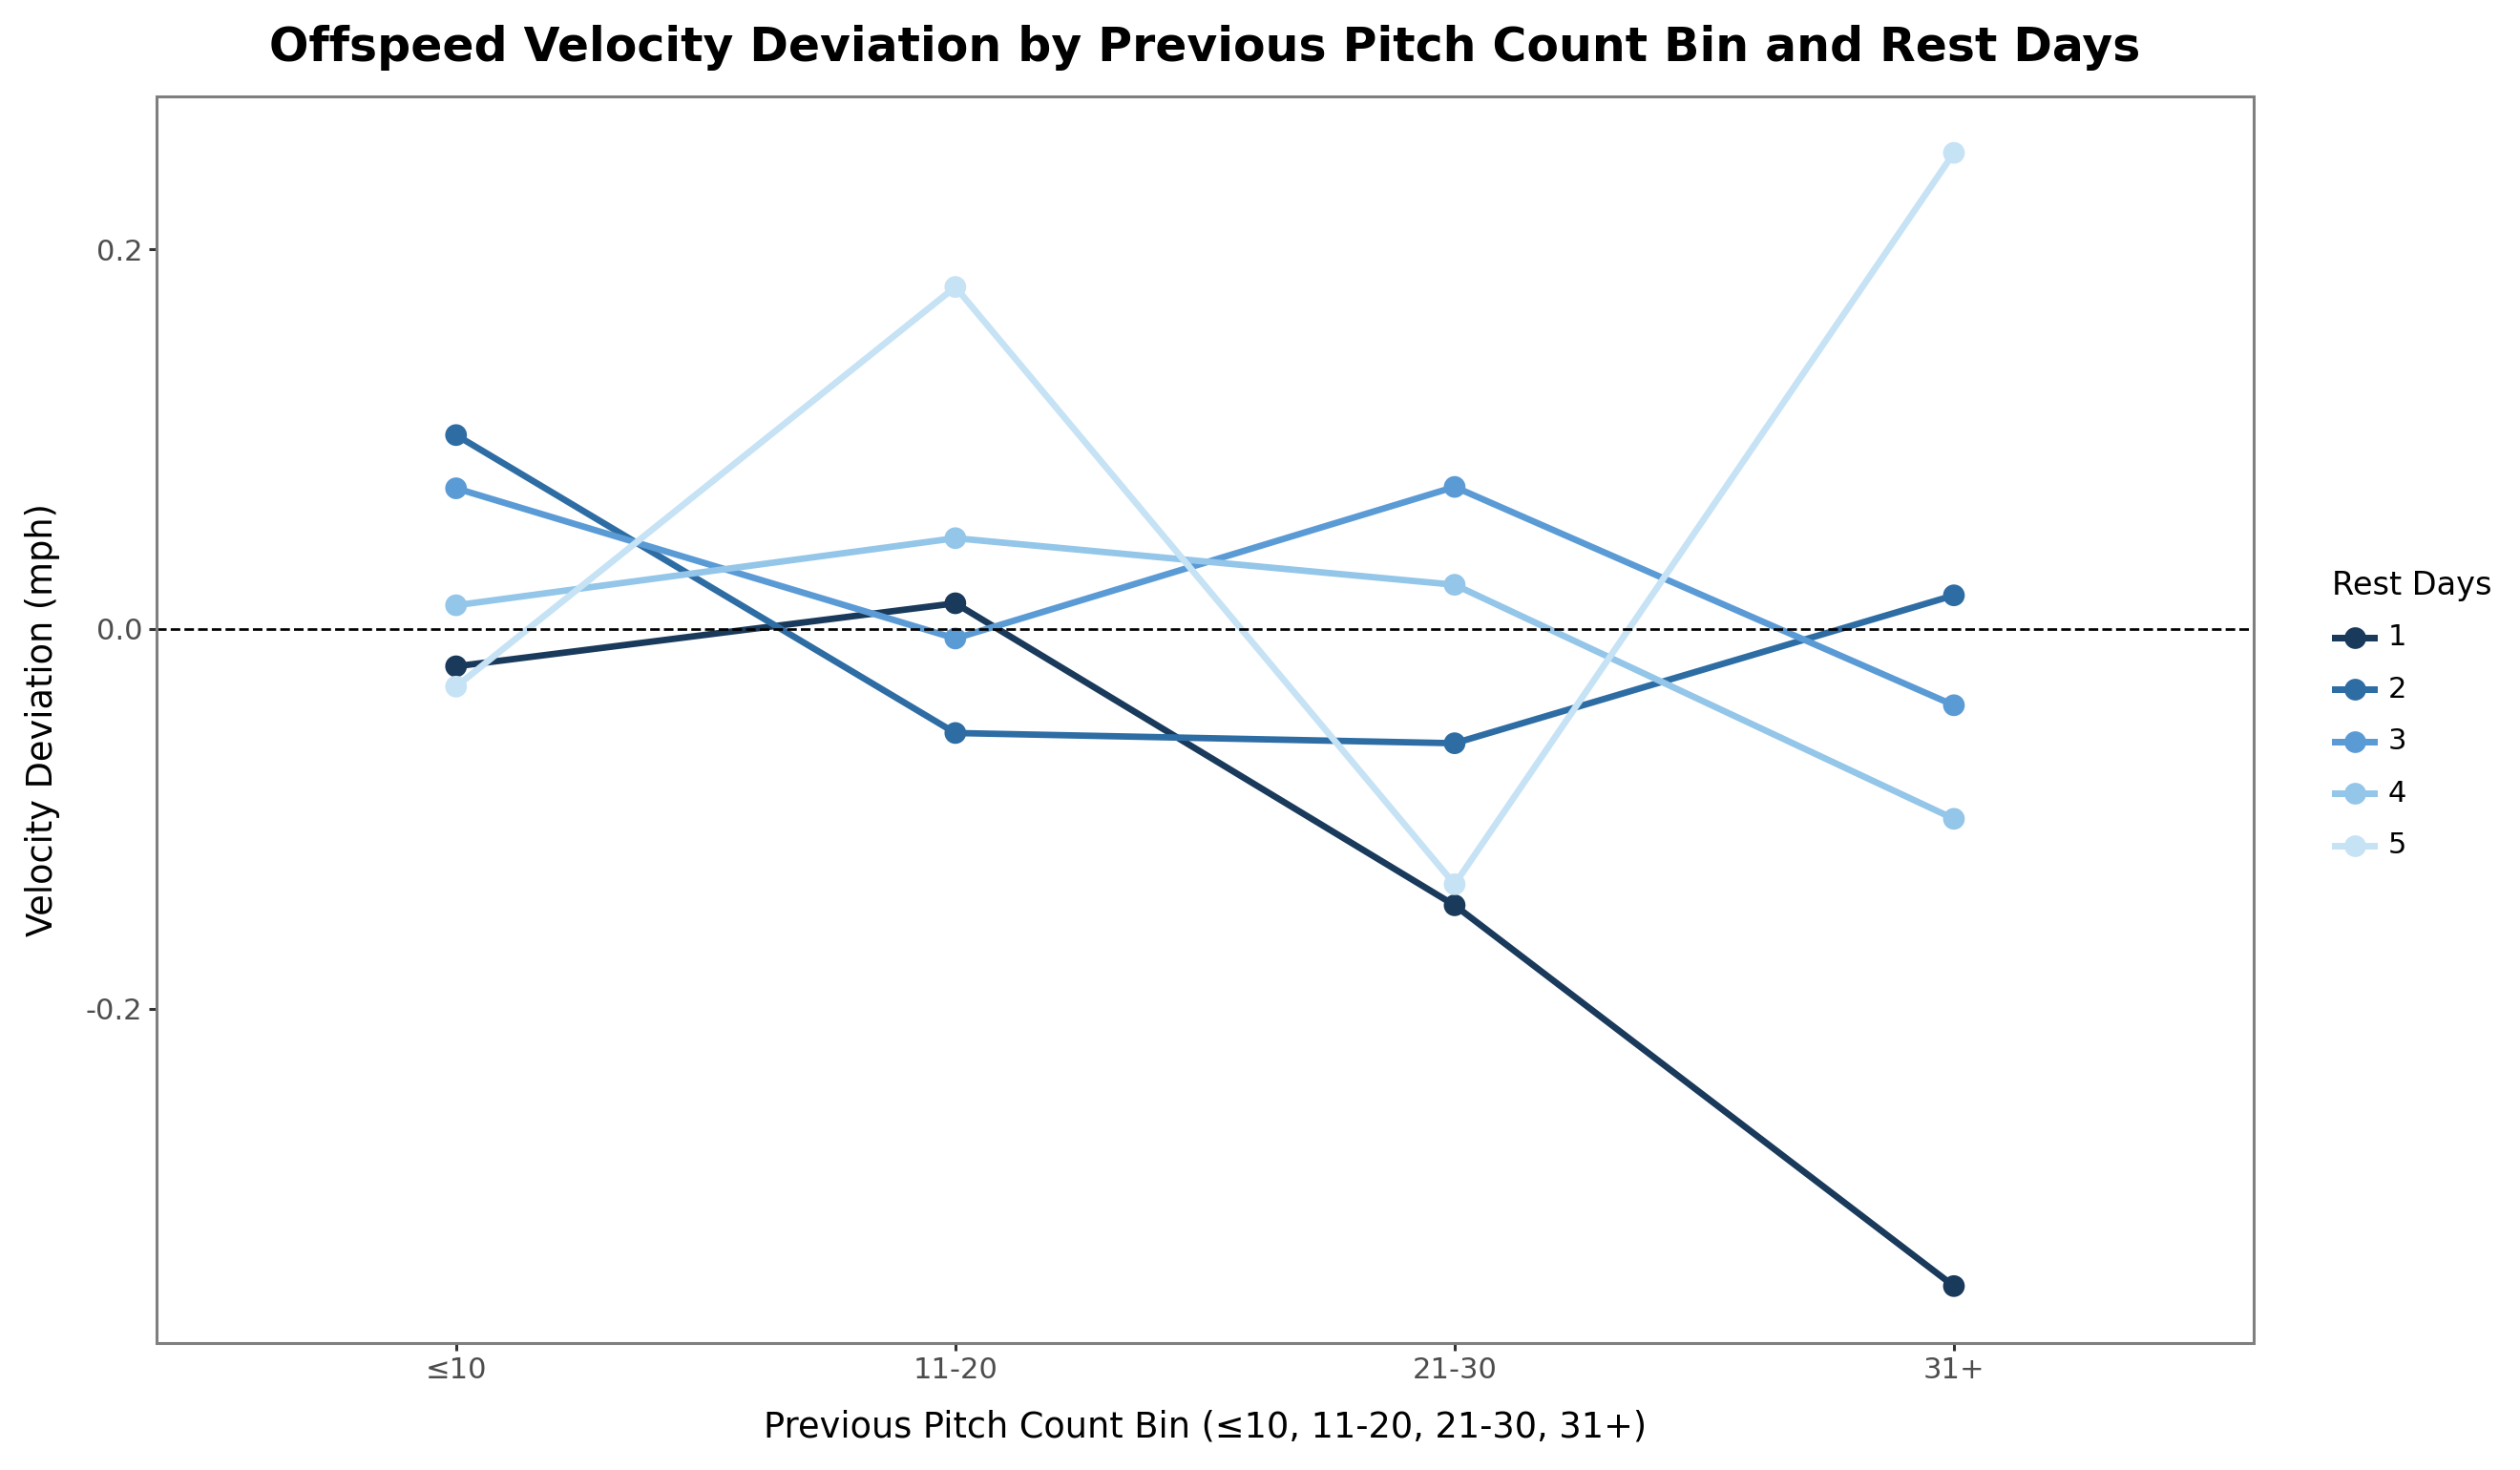

In [139]:
# Offspeed velocity: previous pitch-count bin x rest-day groups (1-5)
off_velo_plot = (
    complete_outing_table_offspeed
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "off_velo_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "off_velo_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("off_velo_deviation").alias("avg_velo_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_velo_plot["prev_pitch_bin"] = pd.Categorical(
    off_velo_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_velo_plot = off_velo_plot.sort_values(["rest_days", "prev_pitch_bin"])
off_velo_plot["rest_days_str"] = off_velo_plot["rest_days"].astype(str)

(
    ggplot(
        off_velo_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_velo_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Offspeed Velocity Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Velocity Deviation (mph)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

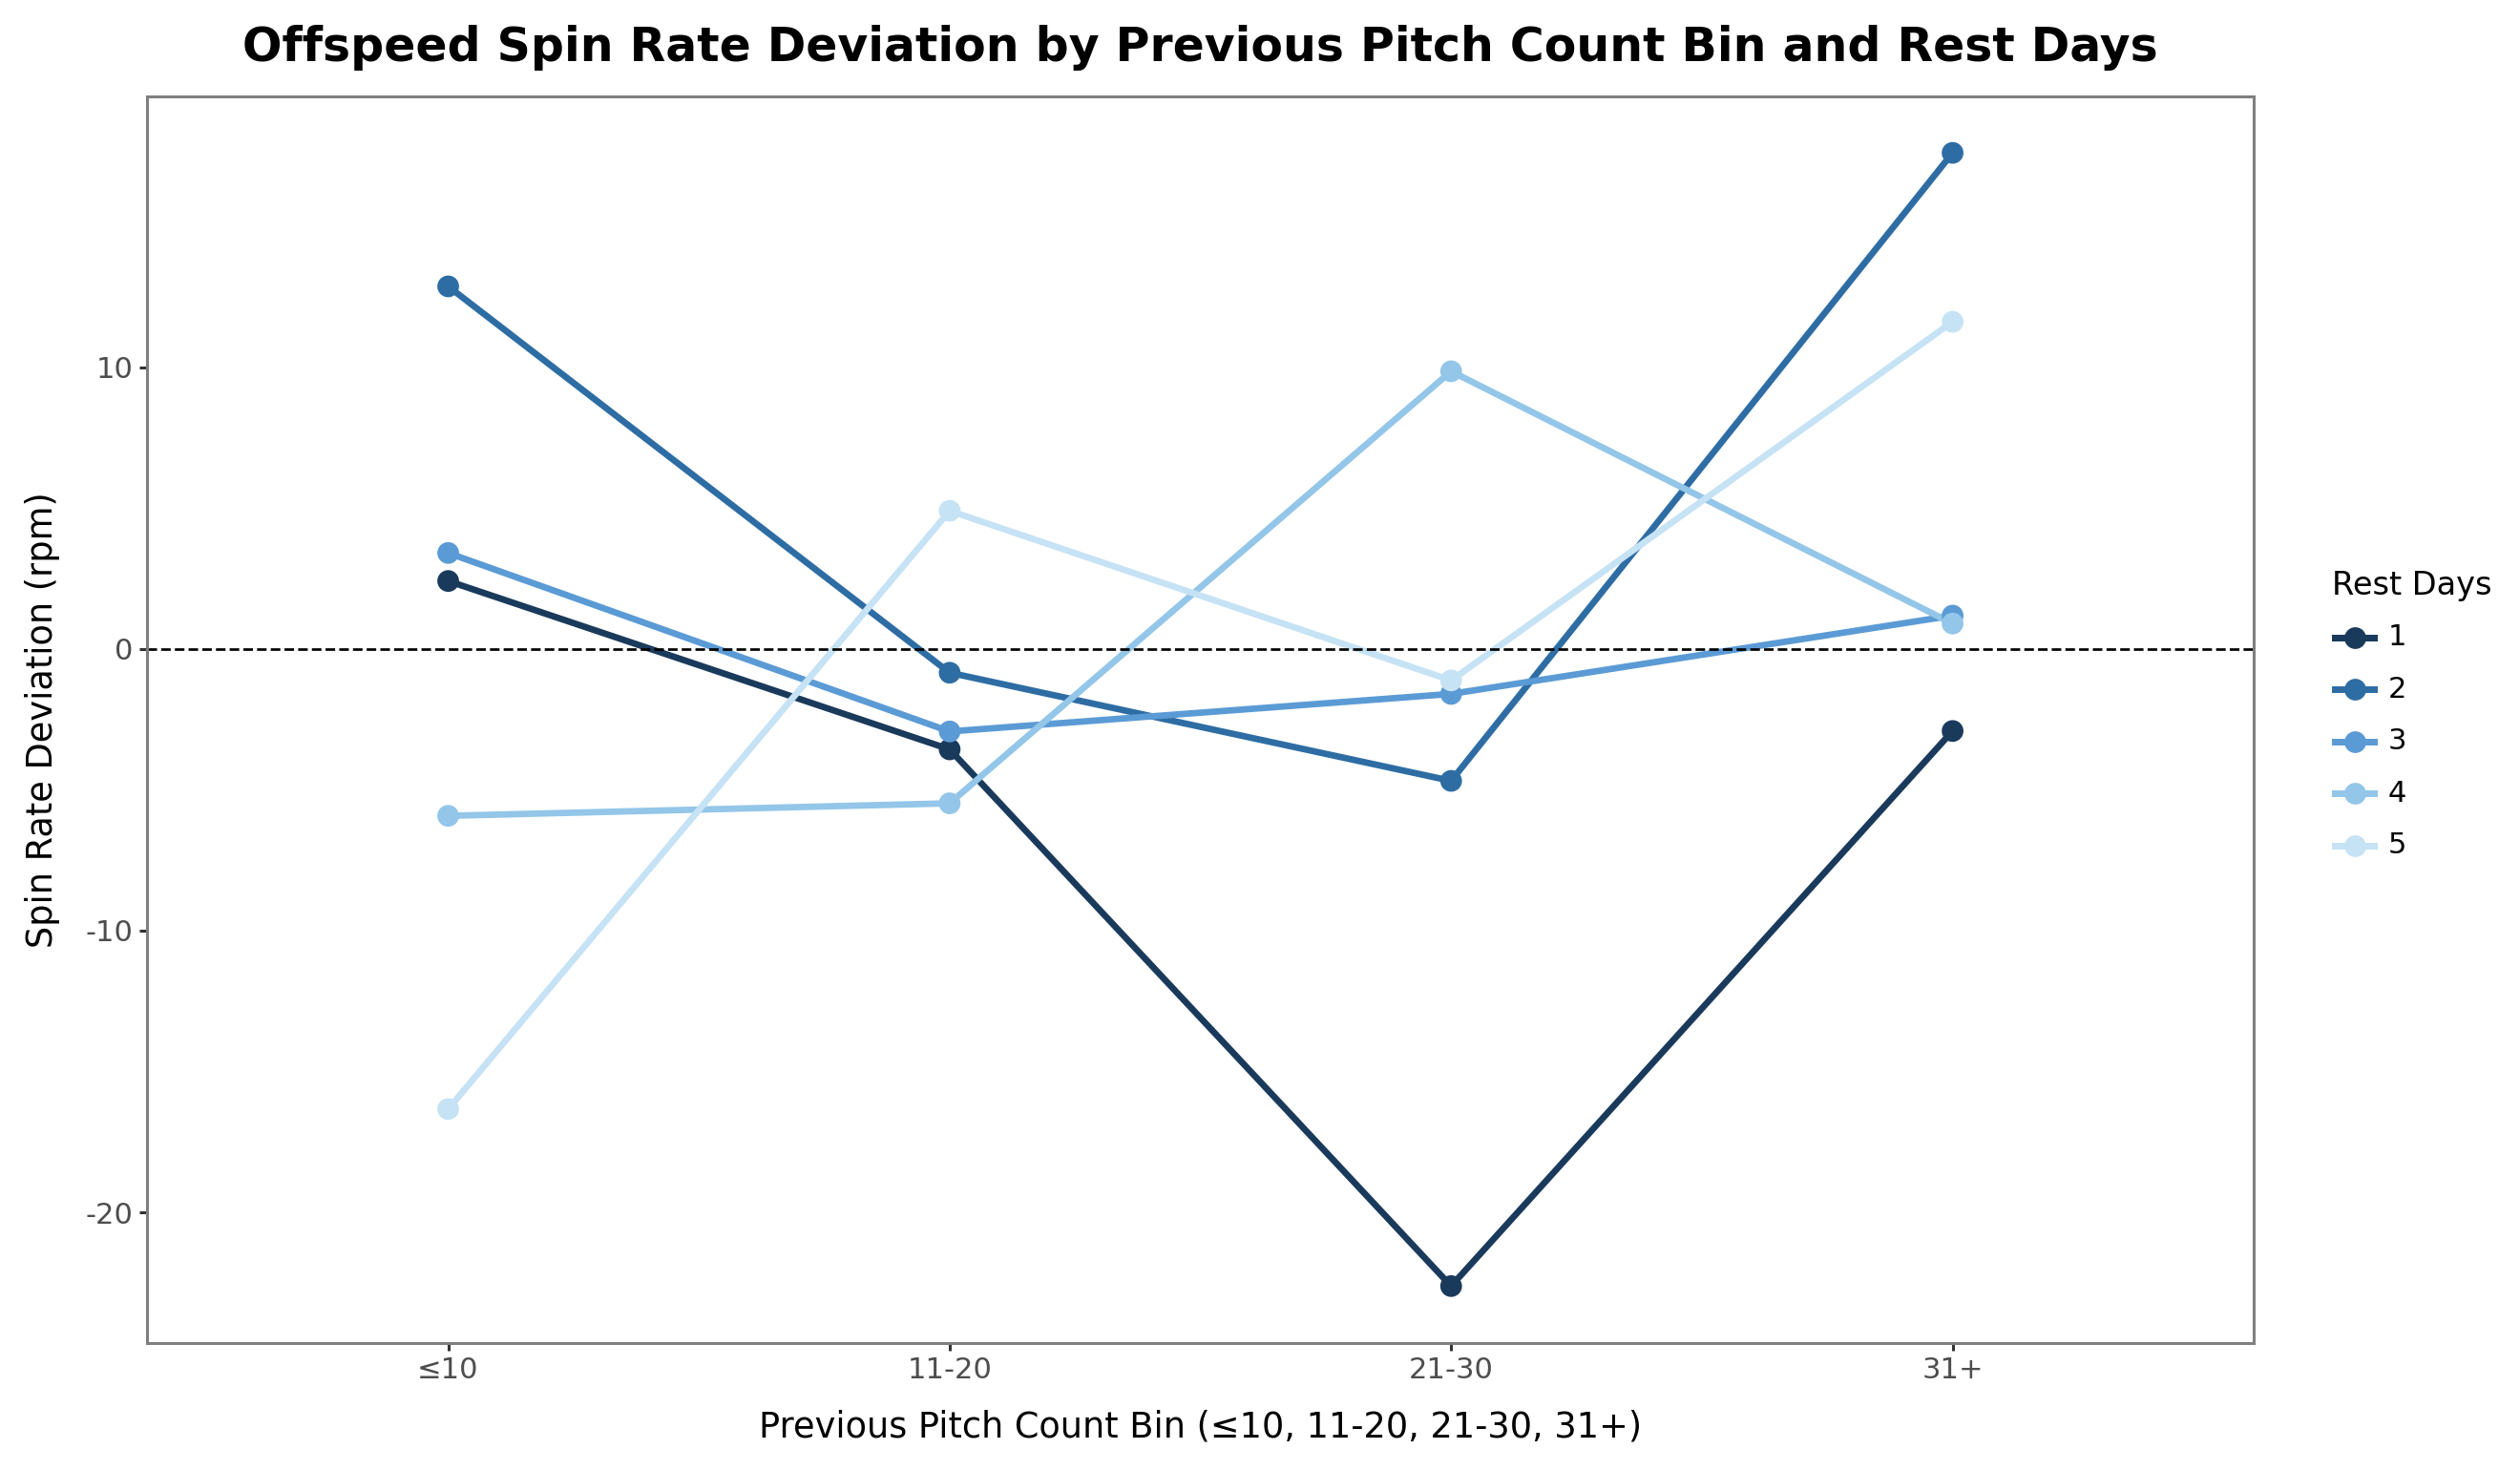

In [140]:
# Offspeed spin rate: previous pitch-count bin x rest-day groups (1-5)
off_spin_plot = (
    complete_outing_table_offspeed
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "off_spin_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "off_spin_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("off_spin_deviation").alias("avg_spin_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_spin_plot["prev_pitch_bin"] = pd.Categorical(
    off_spin_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_spin_plot = off_spin_plot.sort_values(["rest_days", "prev_pitch_bin"])
off_spin_plot["rest_days_str"] = off_spin_plot["rest_days"].astype(str)

(
    ggplot(
        off_spin_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Offspeed Spin Rate Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Spin Rate Deviation (rpm)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

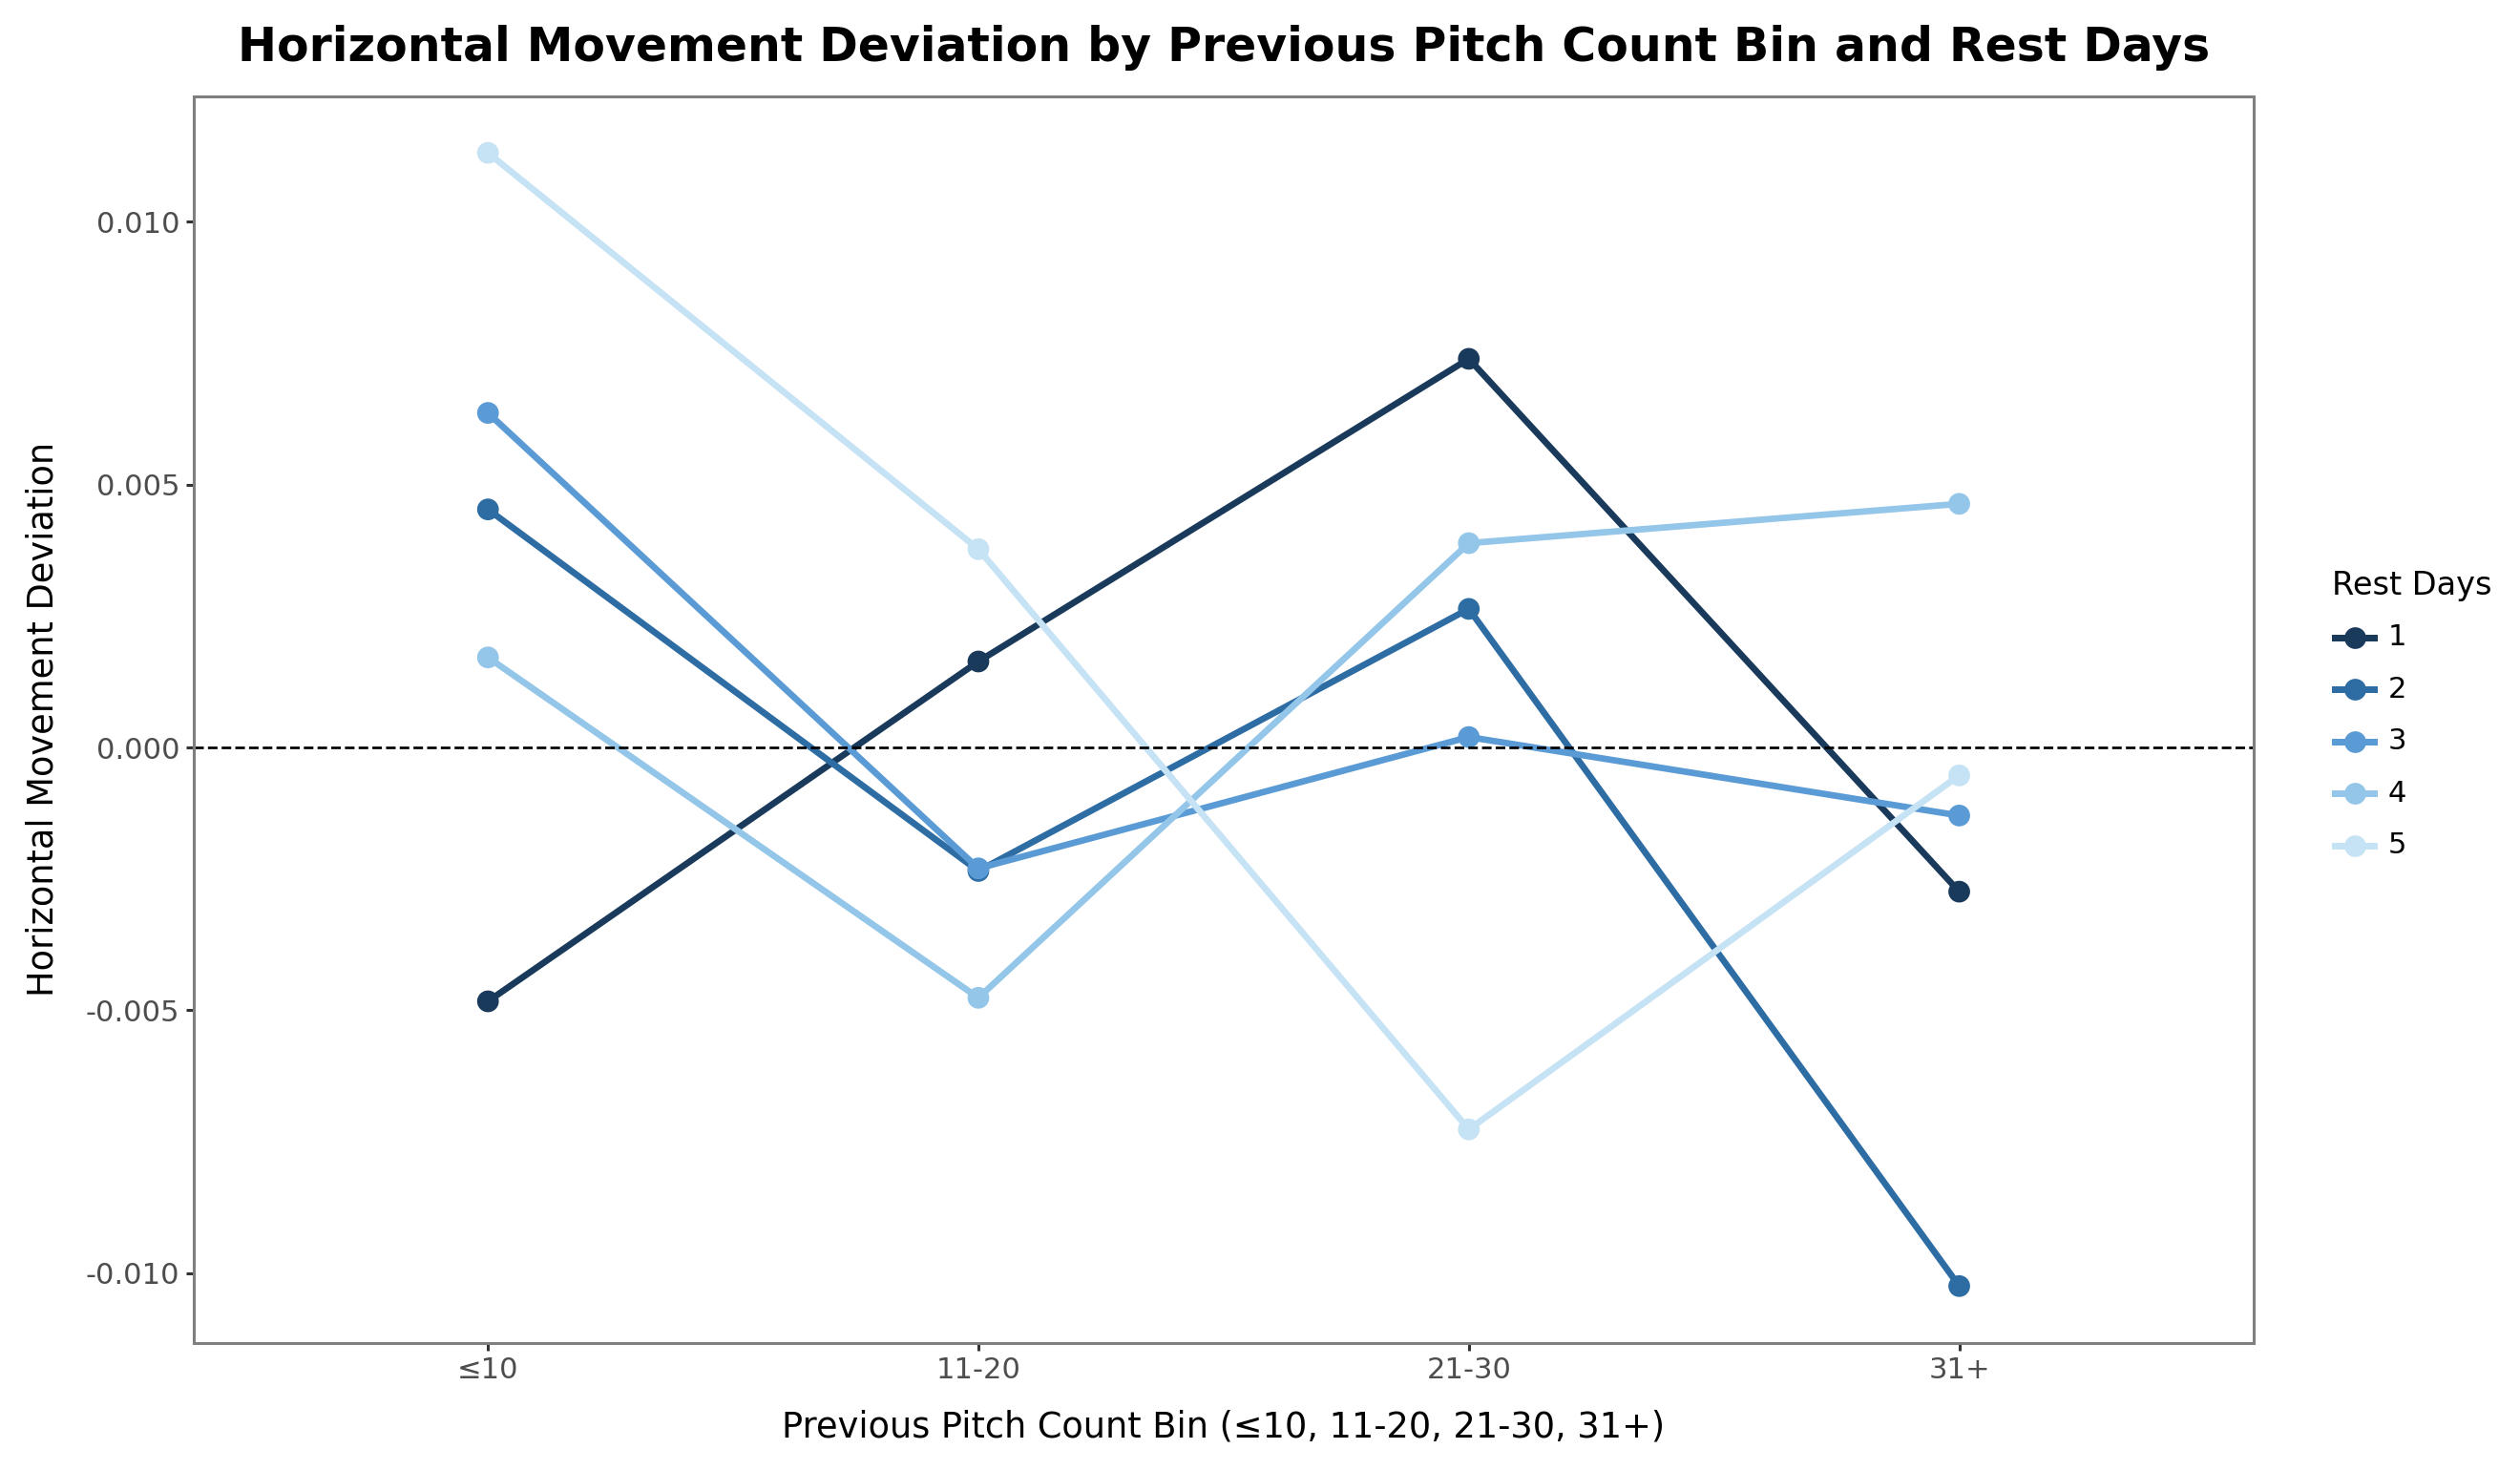

In [141]:
# Horizontal movement: previous pitch-count bin x rest-day groups (1-5)
movement_table = complete_outing_table.select([
    "rest_days",
    "prev_pitch_bin",
    "h_movement_deviation",
    "v_movement_deviation",
])
off_hmov_plot = (
    movement_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "h_movement_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "h_movement_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("h_movement_deviation").alias("avg_hmov_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_hmov_plot["prev_pitch_bin"] = pd.Categorical(
    off_hmov_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_hmov_plot = off_hmov_plot.sort_values(["rest_days", "prev_pitch_bin"])
off_hmov_plot["rest_days_str"] = off_hmov_plot["rest_days"].astype(str)

(
    ggplot(
        off_hmov_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_hmov_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Horizontal Movement Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Horizontal Movement Deviation",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

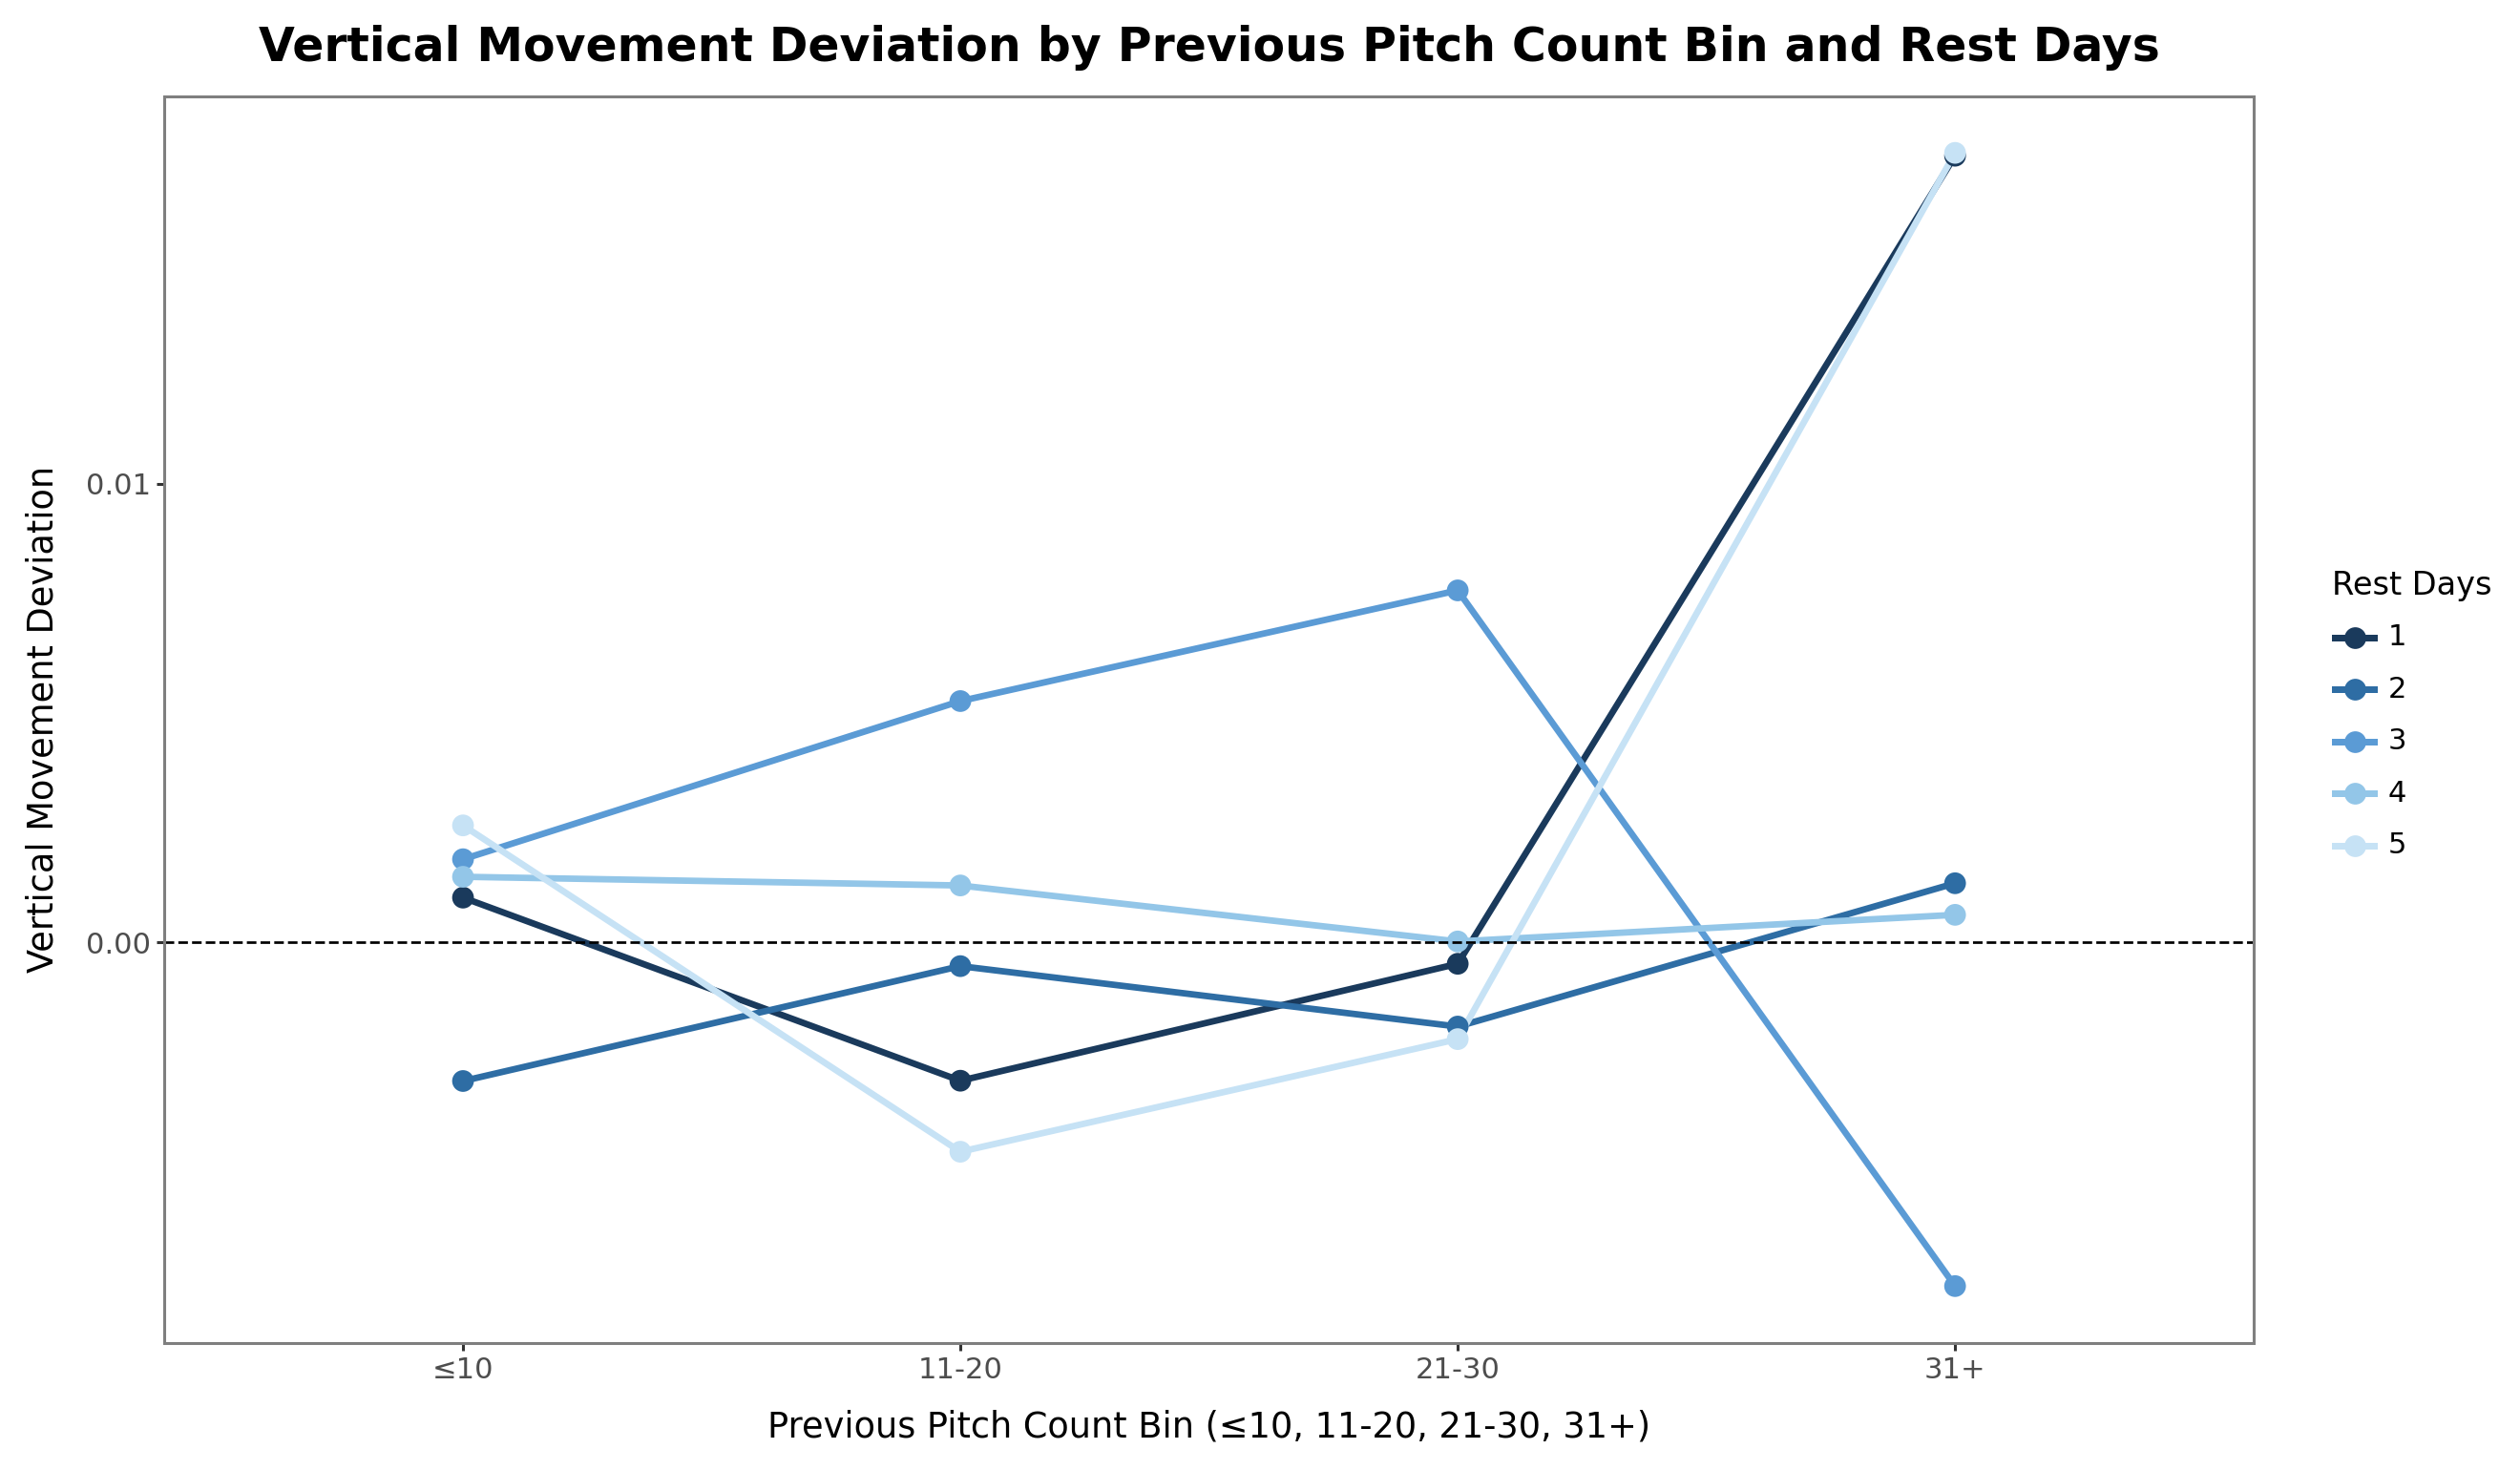

In [142]:
# Vertical movement: previous pitch-count bin x rest-day groups (1-5)
off_vmov_plot = (
    movement_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "v_movement_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "v_movement_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("v_movement_deviation").alias("avg_vmov_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
off_vmov_plot["prev_pitch_bin"] = pd.Categorical(
    off_vmov_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
off_vmov_plot = off_vmov_plot.sort_values(["rest_days", "prev_pitch_bin"])
off_vmov_plot["rest_days_str"] = off_vmov_plot["rest_days"].astype(str)

(
    ggplot(
        off_vmov_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_vmov_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Vertical Movement Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Vertical Movement Deviation",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white"),
        plot_background=element_rect(fill="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

In [143]:
(slider_metrics := (
    relievers
    .filter(pl.col("pitch_type_abbr") == "SL")
    .drop_nulls(["velocity", "spin_rate", "pitcher_id", "game_id", "year"])
    .group_by(["pitcher_id", "game_id", "year"])
    .agg([
        pl.mean("velocity").alias("mean_slider_velo"),
        pl.mean("spin_rate").alias("mean_slider_spin"),
        pl.len().alias("slider_pitch_count"),
    ])
    .filter(pl.col("slider_pitch_count") >= min_family_pitches)
    .with_columns([
        pl.col("mean_slider_velo").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_velo"),
        pl.col("mean_slider_spin").mean().over(["pitcher_id", "year"]).alias("season_avg_slider_spin"),
    ])
    .with_columns([
        (pl.col("mean_slider_velo") - pl.col("season_avg_slider_velo")).alias("slider_velo_deviation"),
        (pl.col("mean_slider_spin") - pl.col("season_avg_slider_spin")).alias("slider_spin_deviation"),
    ])
)).head(5)

pitcher_id,game_id,year,mean_slider_velo,mean_slider_spin,slider_pitch_count,season_avg_slider_velo,season_avg_slider_spin,slider_velo_deviation,slider_spin_deviation
i64,i64,i32,f64,f64,u32,f64,f64,f64,f64
642397,718284,2023,87.0,2309.75,8,87.844589,2400.745002,-0.844589,-90.995002
650556,718354,2023,87.935294,2877.352941,17,87.409726,2915.552534,0.525568,-38.199593
650895,662174,2022,88.866667,2132.666667,6,88.439561,2260.686334,0.427106,-128.019667
605177,661429,2022,83.55,2604.0,8,82.8027,2478.186965,0.7473,125.813035
660853,716813,2023,84.827273,2188.363636,11,84.149333,2196.7233,0.67794,-8.359663


In [144]:
(slider_outing_table := (
    complete_outing_table
    .select(["pitcher_id", "game_id", "rest_days", "prev_pitch_count", "prev_pitch_bin"])
    .join(
        slider_metrics.select([
            "pitcher_id", "game_id",
            "season_avg_slider_velo",
            "season_avg_slider_spin",
            "slider_pitch_count",
            "slider_velo_deviation",
            "slider_spin_deviation"
        ]),
        on=["pitcher_id", "game_id"],
        how="inner"   # use "left" if you want to keep outings without enough sliders
    )
)).head(3)

pitcher_id,game_id,rest_days,prev_pitch_count,prev_pitch_bin,season_avg_slider_velo,season_avg_slider_spin,slider_pitch_count,slider_velo_deviation,slider_spin_deviation
i64,i64,i64,u32,str,f64,f64,u32,f64,f64
445276,634531,2,19,"""11-20""",81.754417,2419.669167,5,1.585583,265.730833
445276,634363,2,23,"""21-30""",81.754417,2419.669167,5,-0.874417,-77.269167
445276,633471,1,11,"""11-20""",81.754417,2419.669167,5,2.605583,118.530833


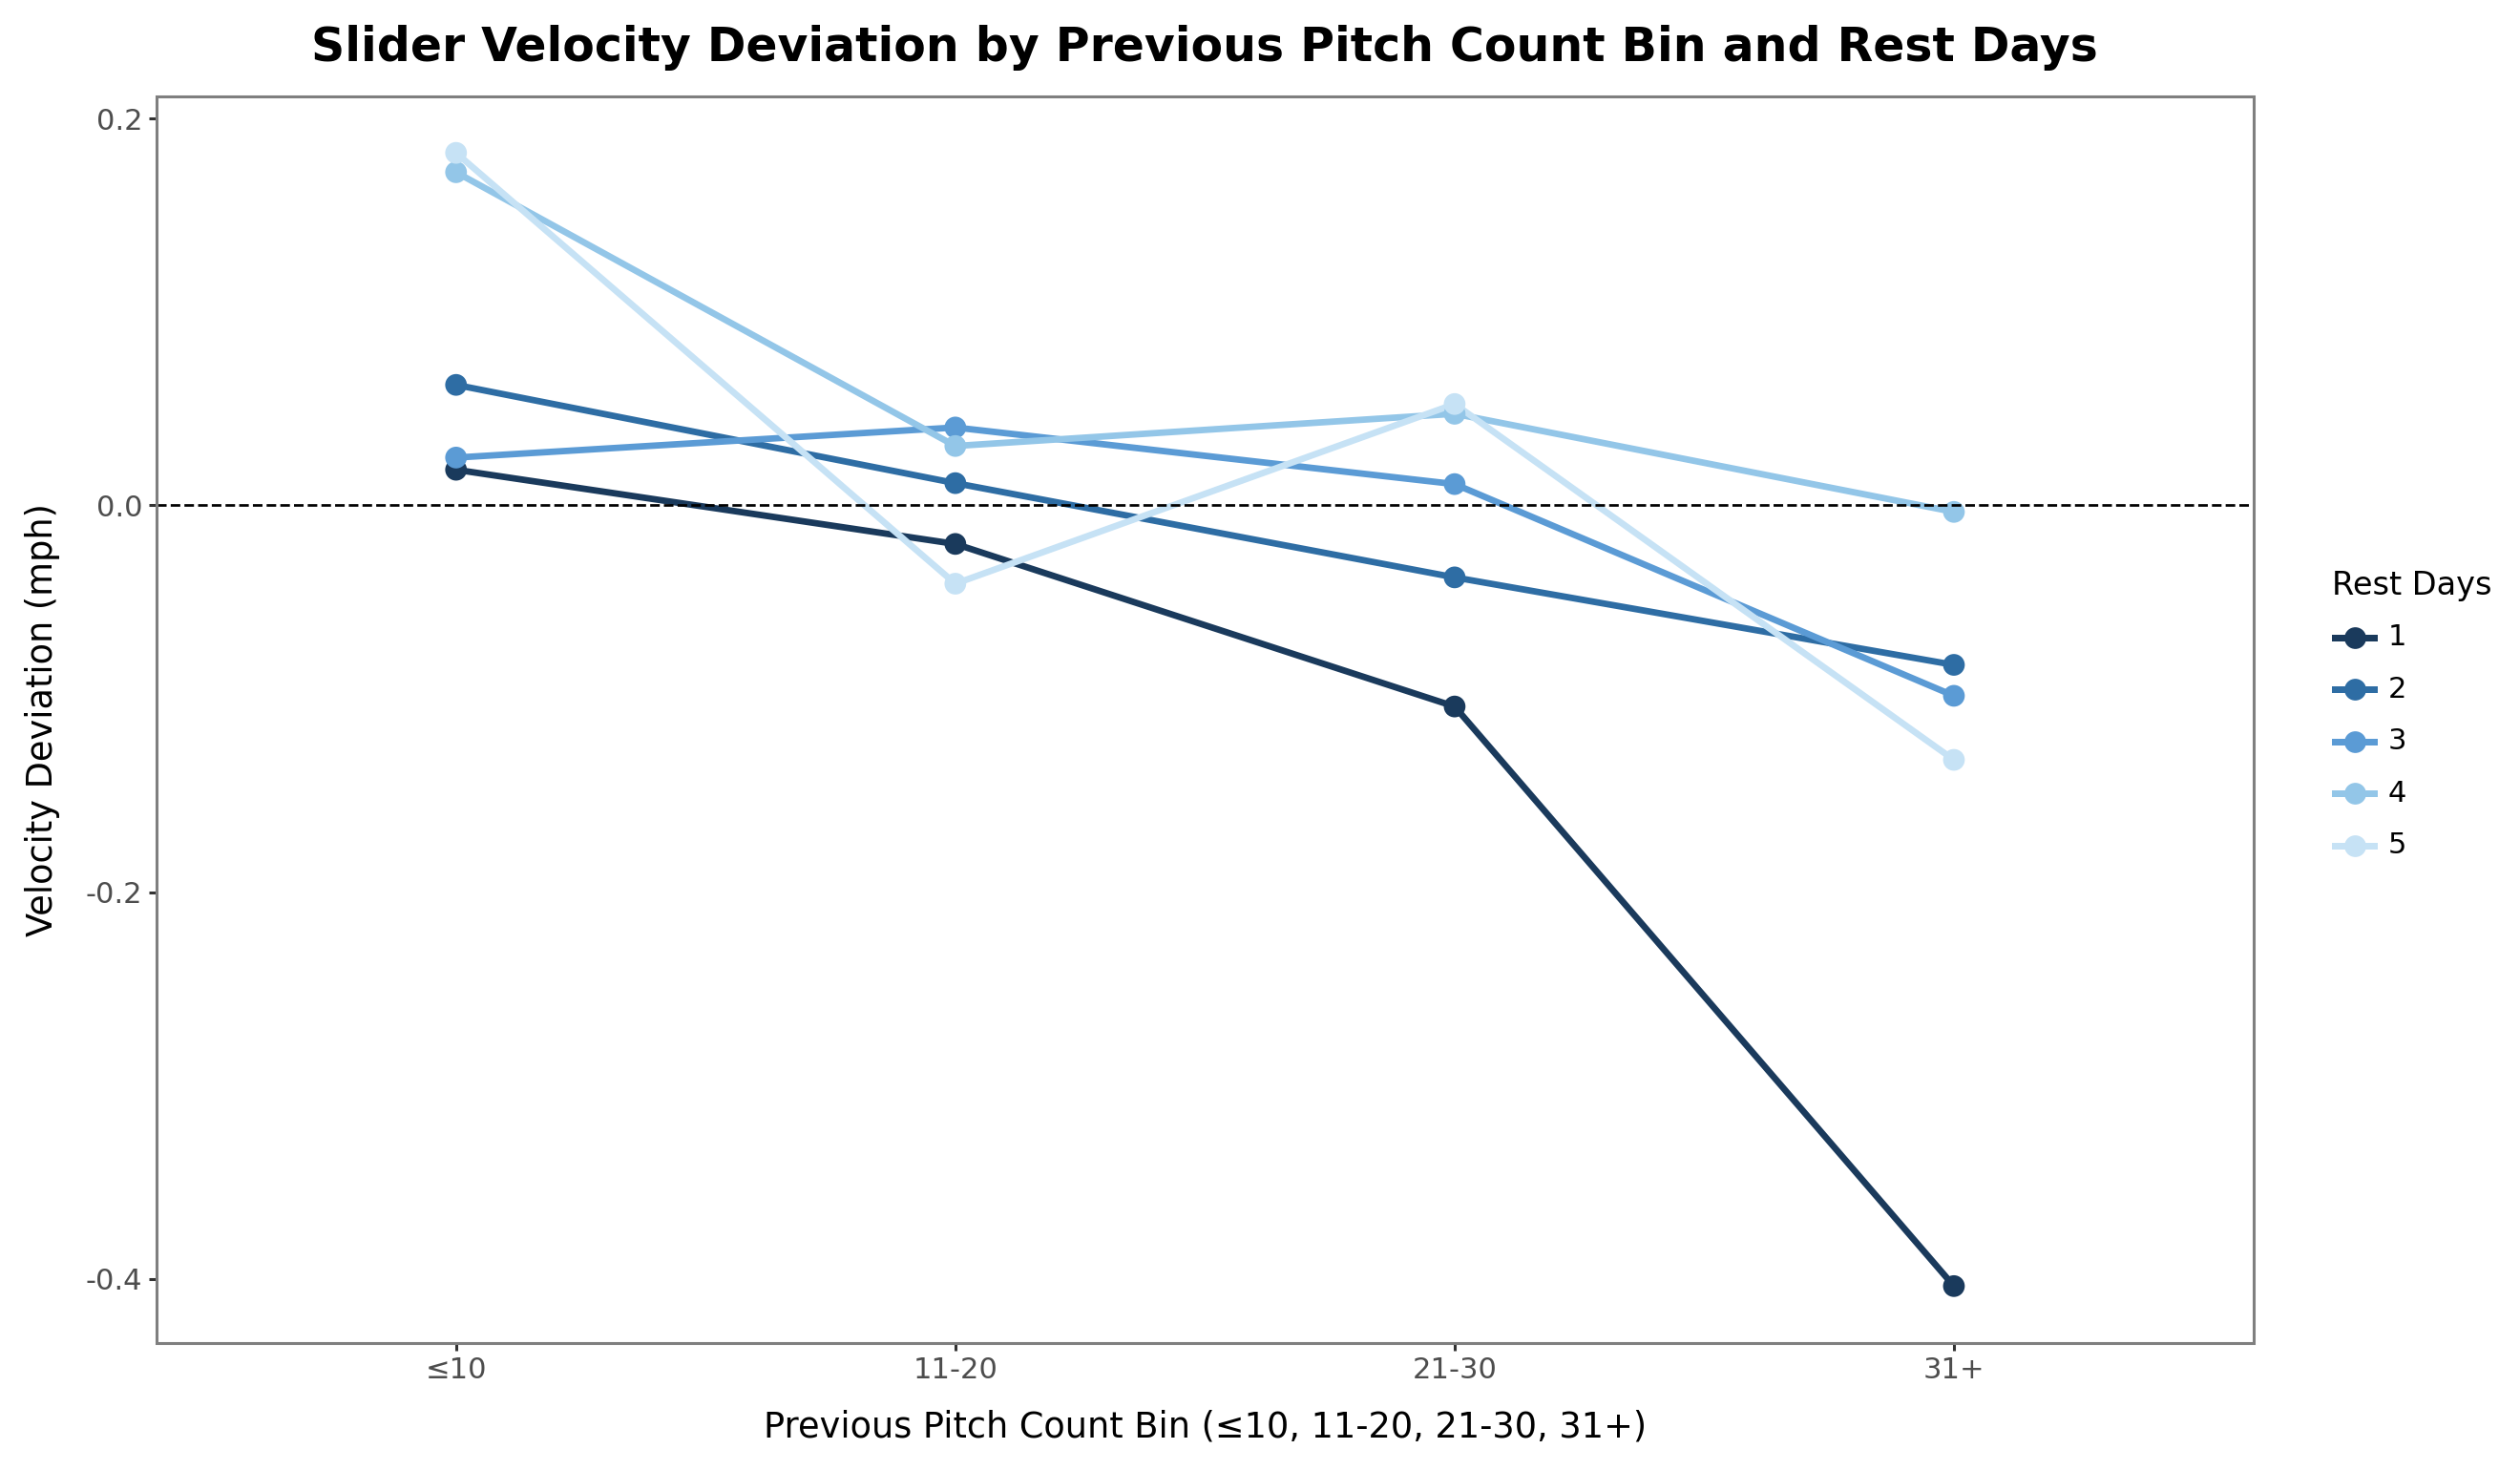

In [145]:
# Slider velocity: previous pitch-count bin x rest-day groups (1-5)
slider_velo_plot = (
    slider_outing_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "slider_velo_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "slider_velo_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("slider_velo_deviation").alias("avg_velo_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
slider_velo_plot["prev_pitch_bin"] = pd.Categorical(
    slider_velo_plot["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
slider_velo_plot = slider_velo_plot.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)
slider_velo_plot["rest_days_str"] = slider_velo_plot["rest_days"].astype(str)

(
    ggplot(
        slider_velo_plot,
        aes(
            x="prev_pitch_bin",
            y="avg_velo_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + labs(
        title="Slider Velocity Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Velocity Deviation (mph)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

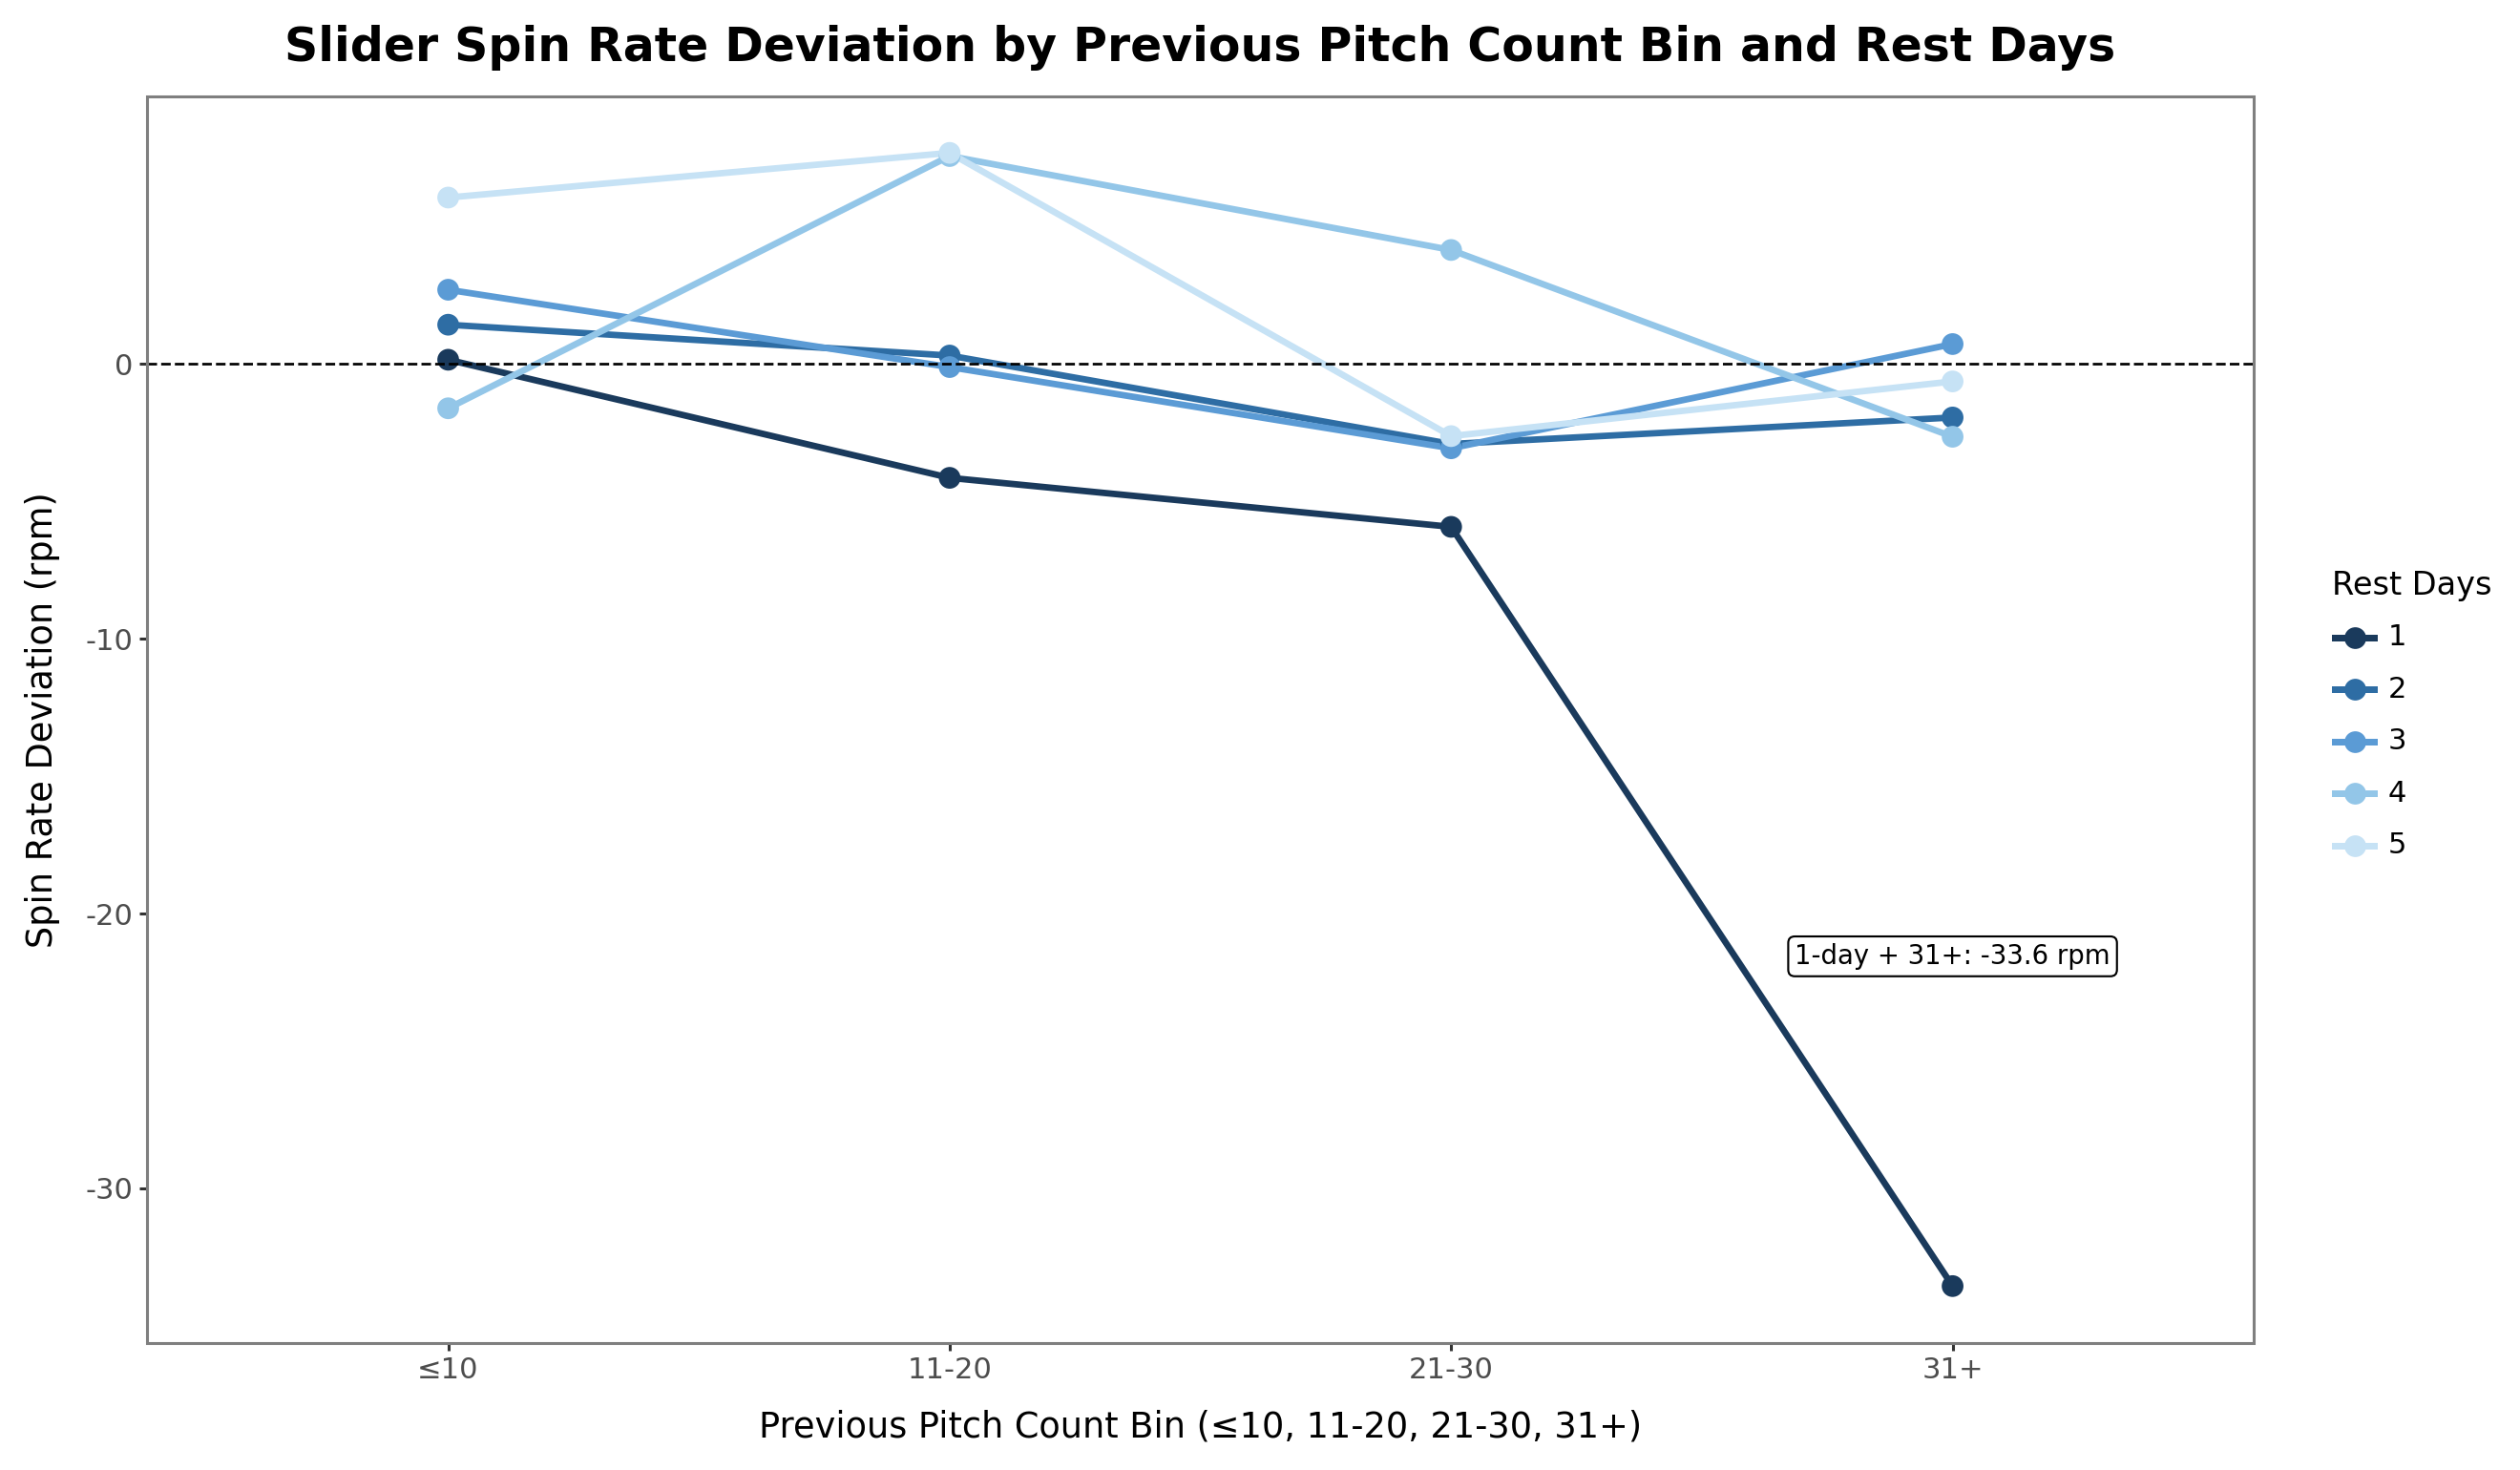

In [146]:
summary_plot_data = (
    slider_outing_table
    .filter((pl.col("rest_days") >= 1) & (pl.col("rest_days") <= 5))
    .select(["rest_days", "prev_pitch_bin", "slider_spin_deviation"])
.drop_nulls(["rest_days", "prev_pitch_bin", "slider_spin_deviation"])
.group_by(["rest_days", "prev_pitch_bin"])
.agg(pl.mean("slider_spin_deviation").alias("avg_spin_deviation"))
.to_pandas()
)

bin_order = ["≤10", "11-20", "21-30", "31+"]
summary_plot_data["prev_pitch_bin"] = pd.Categorical(
    summary_plot_data["prev_pitch_bin"],
    categories=bin_order,
    ordered=True
)
summary_plot_data = summary_plot_data.sort_values(["rest_days", "prev_pitch_bin"]).reset_index(drop=True)
summary_plot_data["rest_days_str"] = summary_plot_data["rest_days"].astype(str)

ann_df = summary_plot_data[
    (summary_plot_data["rest_days"] == 1)
    & (summary_plot_data["prev_pitch_bin"] == "31+")
] .copy()

if not ann_df.empty:
    ann_df["label"] = ann_df["avg_spin_deviation"].map(
        lambda x: f"1-day + 31+: {x:.1f} rpm"
    )
else:
    ann_df = pd.DataFrame(
        columns=["rest_days", "prev_pitch_bin", "avg_spin_deviation", "label"]
    )

(
    ggplot(
        summary_plot_data,
        aes(
            x="prev_pitch_bin",
            y="avg_spin_deviation",
            group="rest_days_str",
            color="rest_days_str",
        ),
    )
    + geom_line(size=1.25)
    + geom_point(size=3.2)
    + geom_hline(yintercept=0, linetype="dashed")
    + scale_color_manual(values=REST_DAY_COLORS)
    + geom_label(
        data=ann_df,
        mapping=aes(x="prev_pitch_bin", y="avg_spin_deviation", label="label"),
        fill="white",
        color="black",
        size=9,
        nudge_y=12,
        show_legend=False,
    )
    + labs(
        title="Slider Spin Rate Deviation by Previous Pitch Count Bin and Rest Days",
        x="Previous Pitch Count Bin (≤10, 11-20, 21-30, 31+)",
        y="Spin Rate Deviation (rpm)",
        color="Rest Days",
    )
    + theme_bw()
    + theme(
        figure_size=(12, 7),
        dpi=110,
        plot_title=element_text(size=16, weight="bold"),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_title=element_text(size=11),
        legend_text=element_text(size=10),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        legend_key=element_rect(fill="white", color="white"),
    )
)

In [147]:


# 1) build outing-level table
outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
    .agg(
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    )
    .sort(["pitcher_id", "date", "game_id"])
    .with_columns(
        pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
    )
    .with_columns(
        pl.when(pl.col("rest_days") >= 5)
        .then(pl.lit("5+"))
        .otherwise(pl.col("rest_days").cast(pl.Int64).cast(pl.Utf8))
        .alias("rest_bin"),

        pl.when(pl.col("prev_pitch_count") <= 10).then(pl.lit("≤10"))
        .when(pl.col("prev_pitch_count") <= 20).then(pl.lit("11-20"))
        .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("21-30"))
        .when(pl.col("prev_pitch_count") > 30).then(pl.lit("31+"))
        .otherwise(None)
        .alias("prev_pitch_bin")
    )
    .filter(pl.col("rest_days").is_between(1, 5))
)

# 2) join outing bins back onto pitch-level data
statcast_binned = (
    relievers
    .join(
        outings.select([
            "pitcher_id", "date", "game_id",
            "rest_days", "rest_bin", "prev_pitch_count", "prev_pitch_bin"
        ]),
        on=["pitcher_id", "date", "game_id"],
        how="inner"
    )
)

# 3) define swings and whiffs
swing_results = [
    "swinging_strike",
    "swinging_strike_blocked",
    "foul",
    "foul_tip",
    "foul_bunt",
    "bunt_foul_tip",
    "missed_bunt",
    "hit_into_play"
]

whiff_results = [
    "swinging_strike",
    "swinging_strike_blocked",
    "missed_bunt"
]

statcast_binned = statcast_binned.with_columns(
    pl.col("pitch_result").is_in(swing_results).alias("swing"),
    pl.col("pitch_result").is_in(whiff_results).alias("whiff")
)

# 4) whiff table by rest x previous workload bin
whiff_table = (
    statcast_binned
    .filter(pl.col("prev_pitch_bin").is_not_null())
    .group_by(["rest_bin", "prev_pitch_bin"])
    .agg(
        pl.col("whiff").sum().alias("whiffs"),
        pl.col("swing").sum().alias("swings"),
        pl.len().alias("pitches")
    )
    .with_columns(
        (pl.col("whiffs") / pl.col("swings")).alias("whiff_rate")
    )
    .sort(["rest_bin", "prev_pitch_bin"])
)

whiff_table

rest_bin,prev_pitch_bin,whiffs,swings,pitches,whiff_rate
str,str,u32,u32,u32,f64
"""1""","""11-20""",7638,29658,62351,0.257536
"""1""","""21-30""",1857,7053,14907,0.263292
"""1""","""31+""",94,458,970,0.20524
"""1""","""≤10""",3387,13311,27491,0.254451
"""2""","""11-20""",12565,48106,101219,0.261194
…,…,…,…,…,…
"""4""","""≤10""",1708,6746,14388,0.253187
"""5+""","""11-20""",2654,10069,21591,0.263581
"""5+""","""21-30""",1380,5595,11741,0.246649


In [148]:
import numpy as np

In [149]:
import polars as pl
import pandas as pd
from plotnine import *

# build outing-level workload/rest table
outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
    .agg(
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    )
    .sort(["pitcher_id", "date", "game_id"])
    .with_columns(
        pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
    )
    .with_columns(
        pl.when(pl.col("prev_pitch_count") <= 10).then(pl.lit("≤10"))
        .when(pl.col("prev_pitch_count") <= 20).then(pl.lit("11-20"))
        .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("21-30"))
        .when(pl.col("prev_pitch_count") > 30).then(pl.lit("31+"))
        .otherwise(None)
        .alias("prev_pitch_bin")
    )
)

# attach previous-workload bin to each pitch
sc = relievers.join(
    outings.select(["pitcher_id", "date", "game_id", "prev_pitch_bin"]),
    on=["pitcher_id", "date", "game_id"],
    how="inner"
)

# keep only pitches that ended a plate appearance
pa_df = (
    sc.filter(
        pl.col("prev_pitch_bin").is_not_null(),
        pl.col("ab_result").is_not_null()
    )
    .with_columns(
        pl.when(pl.col("ab_result") == "strikeout")
        .then(pl.lit(1))
        .when(pl.col("ab_result") == "strikeout_double_play")
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .alias("is_k")
    )
    .group_by("prev_pitch_bin")
    .agg(
        pl.len().alias("plate_appearances"),
        pl.col("is_k").sum().alias("strikeouts")
    )
    .with_columns(
        (pl.col("strikeouts") / pl.col("plate_appearances")).alias("k_rate")
    )
    .sort("prev_pitch_bin")
    .to_pandas()
)

pa_df["prev_pitch_bin"] = pd.Categorical(
    pa_df["prev_pitch_bin"],
    categories=["≤10", "11-20", "21-30", "31+"],
    ordered=True
)

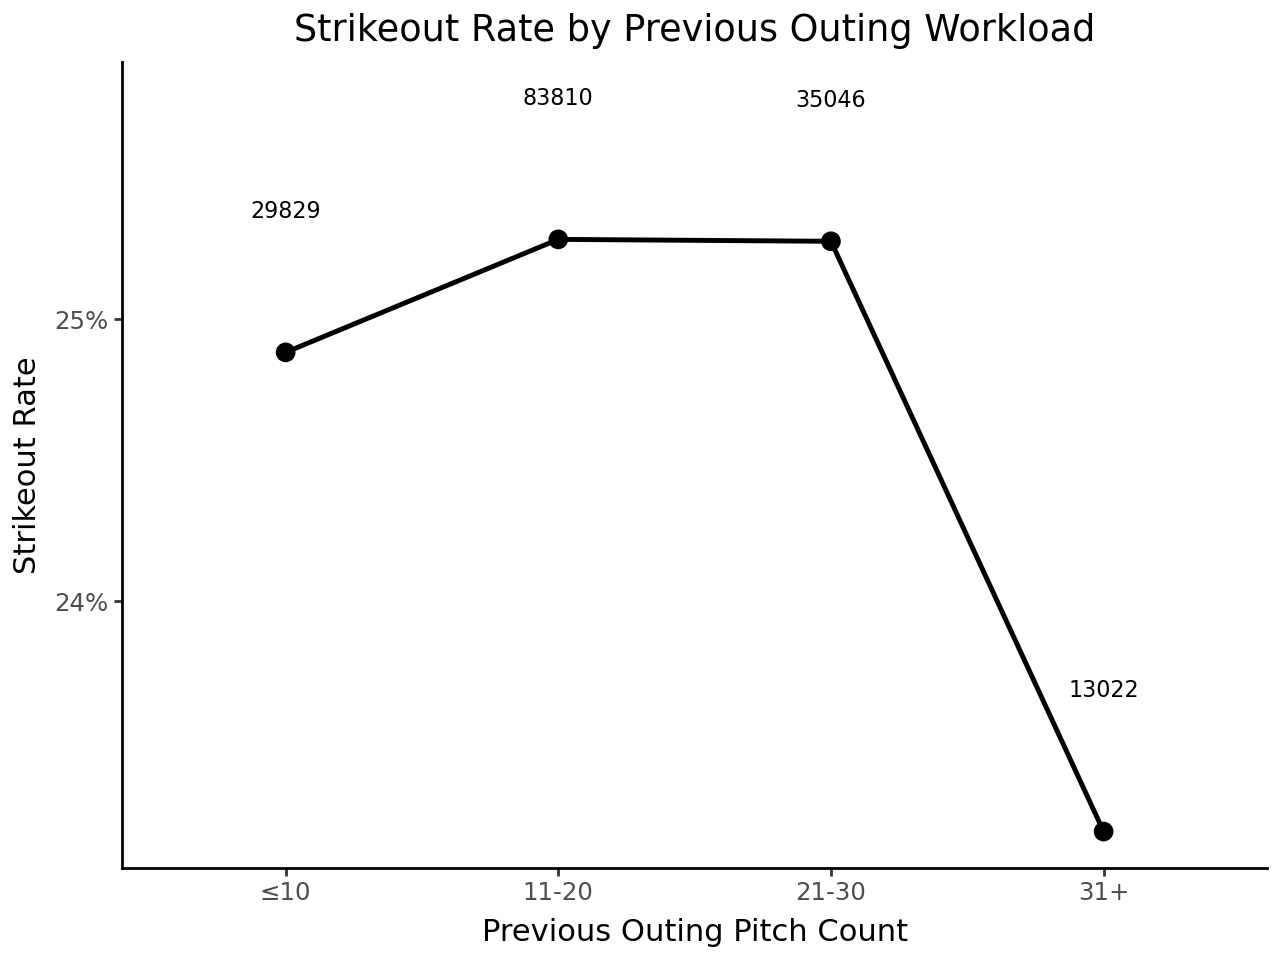

In [150]:
(
    ggplot(pa_df, aes(x="prev_pitch_bin", y="k_rate", group=1))
    + geom_line(size=1)
    + geom_point(size=3)
    + geom_text(aes(label="plate_appearances"), nudge_y=0.005, size=8)
    + scale_y_continuous(labels=lambda x: [f"{v:.0%}" for v in x])
    + labs(
        title="Strikeout Rate by Previous Outing Workload",
        x="Previous Outing Pitch Count",
        y="Strikeout Rate"
    )
    + theme_classic()
)

## Presentation Stats: Two In-Game Outcomes
These two outcomes are game-relevant and easy to explain in slides:
1. Whiff rate by rest day and previous outing workload.
2. Strikeout rate by rest day and previous outing workload.

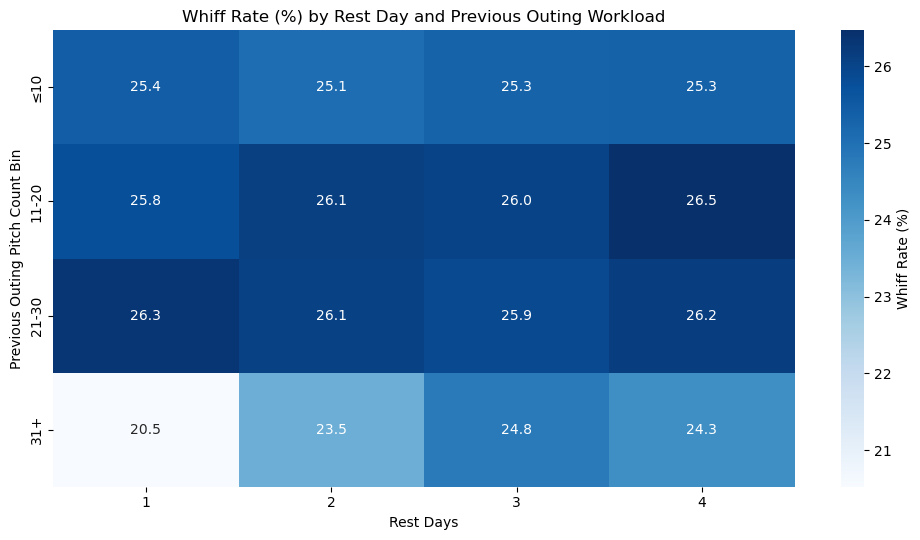

,rest_bin,prev_pitch_bin,whiff_rate_pct,swings
0,1,11-20,25.75,29658
1,1,21-30,26.33,7053
2,1,31+,20.52,458
3,1,≤10,25.45,13311
4,2,11-20,26.12,48106
5,2,21-30,26.05,18058
6,2,31+,23.48,3607
7,2,≤10,25.07,16751
8,3,11-20,26.03,35882
9,3,21-30,25.91,17543


In [152]:
# 1) Whiff rate (%) by rest day x previous outing workload bin
whiff_plot_df = (
    whiff_table
    .filter(
        pl.col("rest_bin").is_in(["1", "2", "3", "4", "5"])
        & pl.col("prev_pitch_bin").is_in(["≤10", "11-20", "21-30", "31+"])
    )
    .with_columns((pl.col("whiff_rate") * 100).alias("whiff_rate_pct"))
    .select(["rest_bin", "prev_pitch_bin", "whiff_rate_pct", "swings"])
    .to_pandas()
)

whiff_pivot = whiff_plot_df.pivot(
    index="prev_pitch_bin",
    columns="rest_bin",
    values="whiff_rate_pct"
).reindex(["≤10", "11-20", "21-30", "31+"])

plt.figure(figsize=(10, 5.5))
sns.heatmap(
    whiff_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Whiff Rate (%)"}
)
plt.title("Whiff Rate (%) by Rest Day and Previous Outing Workload")
plt.xlabel("Rest Days")
plt.ylabel("Previous Outing Pitch Count Bin")
plt.tight_layout()
plt.show()

# Optional quick table for talking points
display(
    whiff_plot_df.sort_values(["rest_bin", "prev_pitch_bin"]).round({"whiff_rate_pct": 2})
)

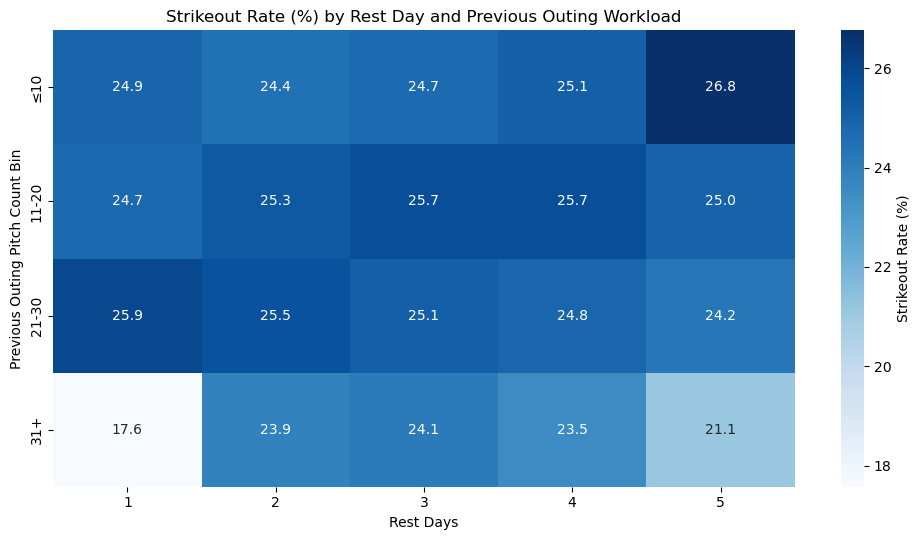

,rest_bin,prev_pitch_bin,k_rate_pct,plate_appearances
8,1,11-20,24.73,15852
6,1,21-30,25.91,3774
14,1,31+,17.57,239
16,1,≤10,24.86,7127
1,2,11-20,25.32,25482
9,2,21-30,25.55,9703
18,2,31+,23.88,1939
17,2,≤10,24.44,8915
5,3,11-20,25.66,19112
11,3,21-30,25.08,9411


In [154]:
# 2) Strikeout rate (%) by rest day x previous outing workload bin
k_results = ["strikeout", "strikeout_double_play"]

# Build a self-contained outing table so this cell is robust even if 'outings' is redefined above
k_outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
.agg([
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    ])
    .sort(["pitcher_id", "date", "game_id"])
.with_columns([
        pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
    ])
    .with_columns([
        pl.col("rest_days").cast(pl.Int64).cast(pl.Utf8).alias("rest_bin"),
        pl.when(pl.col("prev_pitch_count") <= 10).then(pl.lit("≤10"))
        .when(pl.col("prev_pitch_count") <= 20).then(pl.lit("11-20"))
        .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("21-30"))
        .when(pl.col("prev_pitch_count") > 30).then(pl.lit("31+"))
        .otherwise(None)
        .alias("prev_pitch_bin")
    ])
    .filter(pl.col("rest_days").is_between(1, 5))
)

k_plot_df = (
    relievers
    .join(
        k_outings.select([
            "pitcher_id", "date", "game_id", "rest_bin", "prev_pitch_bin"
        ]),
        on=["pitcher_id", "date", "game_id"],
        how="inner"
    )
    .filter(
        pl.col("ab_result").is_not_null()
        & pl.col("rest_bin").is_in(["1", "2", "3", "4", "5"])
        & pl.col("prev_pitch_bin").is_in(["≤10", "11-20", "21-30", "31+"])
    )
    .with_columns(
        pl.col("ab_result").is_in(k_results).cast(pl.Int8).alias("is_k")
    )
    .group_by(["rest_bin", "prev_pitch_bin"] )
    .agg([
        pl.len().alias("plate_appearances"),
        pl.sum("is_k").alias("strikeouts")
    ])
    .with_columns((pl.col("strikeouts") / pl.col("plate_appearances") * 100).alias("k_rate_pct"))
    .select(["rest_bin", "prev_pitch_bin", "k_rate_pct", "plate_appearances"] )
    .to_pandas()
)

k_pivot = k_plot_df.pivot(
    index="prev_pitch_bin",
    columns="rest_bin",
    values="k_rate_pct"
).reindex(["≤10", "11-20", "21-30", "31+"])

plt.figure(figsize=(10, 5.5))
sns.heatmap(
    k_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Strikeout Rate (%)"}
)
plt.title("Strikeout Rate (%) by Rest Day and Previous Outing Workload")
plt.xlabel("Rest Days")
plt.ylabel("Previous Outing Pitch Count Bin")
plt.tight_layout()
plt.show()

# Optional quick table for talking points
display(
    k_plot_df.sort_values(["rest_bin", "prev_pitch_bin"]).round({"k_rate_pct": 2})
)

## Deeper Trend View (Simplified Bins)
To make the signal clearer for slides, collapse bins to:
- Previous workload: `<=20` vs `21+`
- Rest days: `1-2` (short) vs `3-5` (long)

This section plots Whiff% and K% with 95% confidence intervals so the trend and uncertainty are both visible.

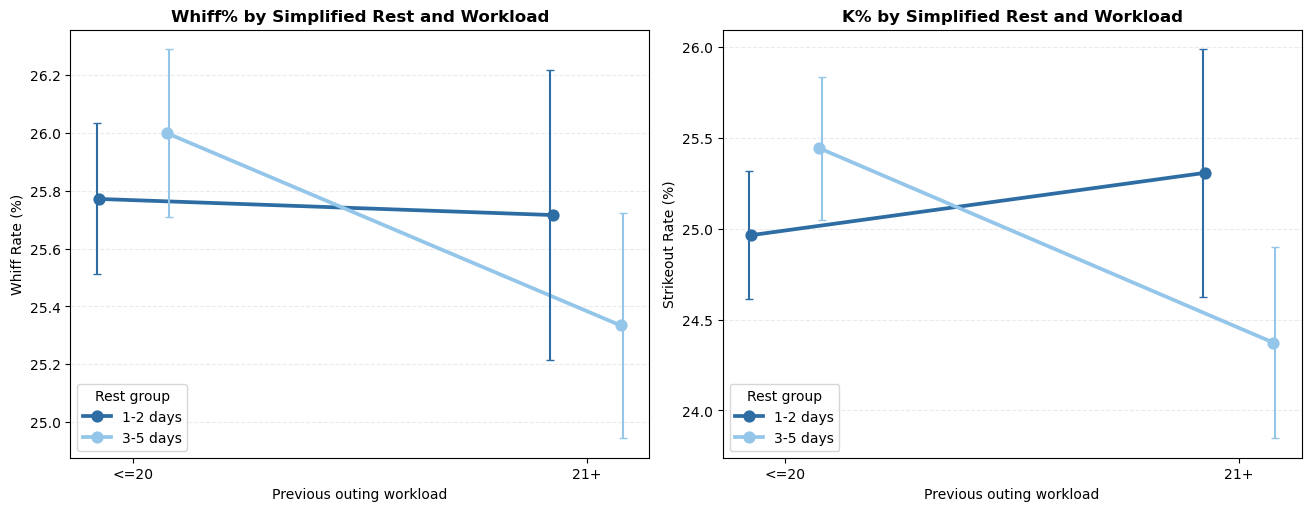

Whiff summary (simplified bins)


,rest_bin_simple,workload_bin_simple,rate_pct,swings
0,3-5 days,21+,25.33,47730
1,1-2 days,<=20,25.77,107826
2,3-5 days,<=20,26.00,87428
3,1-2 days,21+,25.72,29176


Strikeout summary (simplified bins)


,rest_bin_simple,workload_bin_simple,rate_pct,pa
0,3-5 days,<=20,25.44,46899
1,1-2 days,<=20,24.97,57376
2,1-2 days,21+,25.31,15655
3,3-5 days,21+,24.37,25486


In [155]:
# Build a robust base outing table with simplified bins
base_outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
.agg([
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    ])
    .sort(["pitcher_id", "date", "game_id"])
.with_columns([
        pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
    ])
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_count").is_not_null()
    )
    .with_columns([
        pl.when(pl.col("prev_pitch_count") <= 20)
        .then(pl.lit("<=20"))
        .otherwise(pl.lit("21+"))
        .alias("workload_bin_simple"),
        pl.when(pl.col("rest_days") <= 2)
        .then(pl.lit("1-2 days"))
        .otherwise(pl.lit("3-5 days"))
        .alias("rest_bin_simple")
    ])
)

# Attach simplified bins to pitch-level data
pitch_simple = relievers.join(
    base_outings.select([
        "pitcher_id", "date", "game_id", "workload_bin_simple", "rest_bin_simple"
    ]),
    on=["pitcher_id", "date", "game_id"],
    how="inner"
)

# --- Whiff rate (on swings) ---
swing_results = [
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "foul_bunt", "bunt_foul_tip", "missed_bunt", "hit_into_play"
]
whiff_results = ["swinging_strike", "swinging_strike_blocked", "missed_bunt"]

whiff_simple = (
    pitch_simple
    .with_columns([
        pl.col("pitch_result").is_in(swing_results).cast(pl.Int8).alias("is_swing"),
        pl.col("pitch_result").is_in(whiff_results).cast(pl.Int8).alias("is_whiff")
    ])
    .group_by(["rest_bin_simple", "workload_bin_simple"])
.agg([
        pl.sum("is_whiff").alias("whiffs"),
        pl.sum("is_swing").alias("swings")
    ])
    .filter(pl.col("swings") > 0)
    .with_columns([
        (pl.col("whiffs") / pl.col("swings")).alias("rate")
    ])
    .to_pandas()
)

# --- Strikeout rate (on completed PA) ---
k_results = ["strikeout", "strikeout_double_play"]
k_simple = (
    pitch_simple
    .filter(pl.col("ab_result").is_not_null())
    .with_columns(pl.col("ab_result").is_in(k_results).cast(pl.Int8).alias("is_k"))
    .group_by(["rest_bin_simple", "workload_bin_simple"])
.agg([
        pl.len().alias("pa"),
        pl.sum("is_k").alias("ks")
    ])
    .with_columns((pl.col("ks") / pl.col("pa")).alias("rate"))
    .to_pandas()
)

def add_ci(df, n_col, rate_col):
    # Normal-approx 95% CI; good for large n and slide-level interpretation
    p = df[rate_col]
    n = df[n_col]
    se = (p * (1 - p) / n) ** 0.5
    df["rate_pct"] = p * 100
    df["lower_pct"] = (p - 1.96 * se) * 100
    df["upper_pct"] = (p + 1.96 * se) * 100
    return df

whiff_simple = add_ci(whiff_simple, "swings", "rate")
k_simple = add_ci(k_simple, "pa", "rate")

# Order for cleaner plotting
x_order = ["<=20", "21+"]
hue_order = ["1-2 days", "3-5 days"]
palette_simple = {"1-2 days": "#2e6da4", "3-5 days": "#93c6e8"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, df, ylab, title in [
    (axes[0], whiff_simple, "Whiff Rate (%)", "Whiff% by Simplified Rest and Workload"),
    (axes[1], k_simple, "Strikeout Rate (%)", "K% by Simplified Rest and Workload"),
]:
    sns.pointplot(
        data=df,
        x="workload_bin_simple",
        y="rate_pct",
        hue="rest_bin_simple",
        order=x_order,
        hue_order=hue_order,
        palette=palette_simple,
        dodge=0.15,
        markers="o",
        linestyles="-",
        errorbar=None,
        ax=ax,
    )
    # Add custom CI error bars
    for _, r in df.iterrows():
        x = x_order.index(r["workload_bin_simple"])
        offset = -0.08 if r["rest_bin_simple"] == "1-2 days" else 0.08
        ax.errorbar(
            x + offset,
            r["rate_pct"],
            yerr=[[r["rate_pct"] - r["lower_pct"]], [r["upper_pct"] - r["rate_pct"]]],
            fmt="none",
            ecolor=palette_simple[r["rest_bin_simple"]],
            capsize=3,
            lw=1.5
        )
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Previous outing workload")
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Rest group")

plt.show()

print("Whiff summary (simplified bins)")
display(whiff_simple[["rest_bin_simple", "workload_bin_simple", "rate_pct", "swings"]].round(2))

print("Strikeout summary (simplified bins)")
display(k_simple[["rest_bin_simple", "workload_bin_simple", "rate_pct", "pa"]].round(2))

### 3x3 Heatmap View (Simplified but More Granular)
This keeps a heatmap format while simplifying to:
- Workload bins: `<=15`, `16-30`, `31+`
- Rest bins: `1`, `2-3`, `4-5`

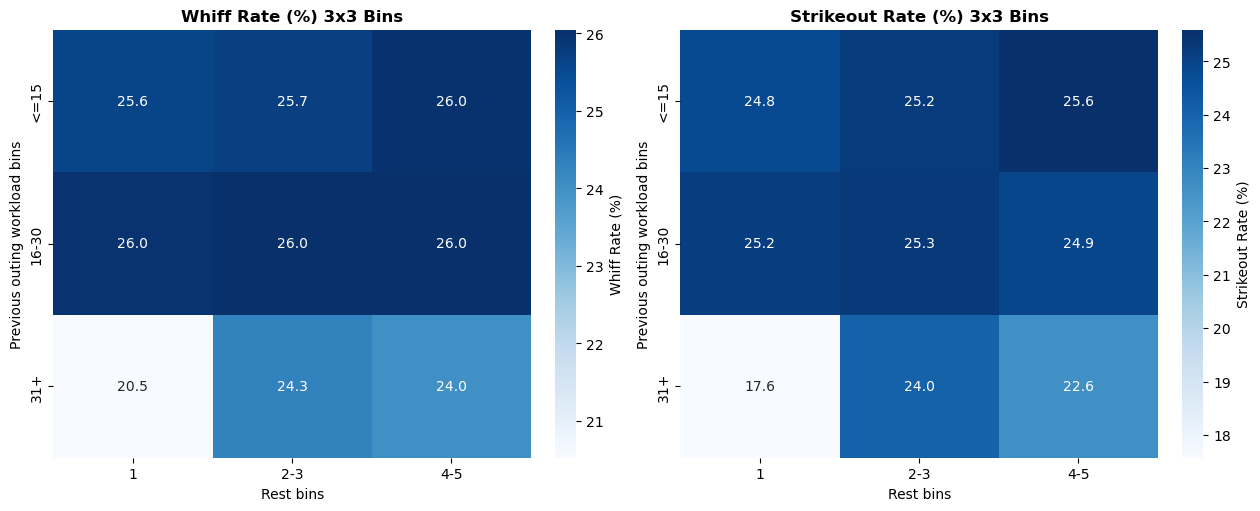

Whiff 3x3 table


rest_bin_3,1,2-3,4-5
workload_bin_3,,,
<=15,25.62,25.72,25.99
16-30,25.96,26.04,26.05
31+,20.52,24.31,24.01


Strikeout 3x3 table


rest_bin_3,1,2-3,4-5
workload_bin_3,,,
<=15,24.80,25.24,25.59
16-30,25.16,25.27,24.92
31+,17.57,24.05,22.63


In [156]:
# 3x3 heatmaps for whiff% and strikeout%
three_bin_outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
.agg([
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    ])
    .sort(["pitcher_id", "date", "game_id"])
.with_columns([
        pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
    ])
    .filter(
        pl.col("rest_days").is_between(1, 5)
        & pl.col("prev_pitch_count").is_not_null()
    )
    .with_columns([
        pl.when(pl.col("prev_pitch_count") <= 15).then(pl.lit("<=15"))
        .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("16-30"))
        .otherwise(pl.lit("31+"))
        .alias("workload_bin_3"),
        pl.when(pl.col("rest_days") == 1).then(pl.lit("1"))
        .when(pl.col("rest_days") <= 3).then(pl.lit("2-3"))
        .otherwise(pl.lit("4-5"))
        .alias("rest_bin_3")
    ])
)

pitch_3x3 = relievers.join(
    three_bin_outings.select([
        "pitcher_id", "date", "game_id", "workload_bin_3", "rest_bin_3"
    ]),
    on=["pitcher_id", "date", "game_id"],
    how="inner"
)

# Whiff% in 3x3 bins
swing_results = [
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "foul_bunt", "bunt_foul_tip", "missed_bunt", "hit_into_play"
]
whiff_results = ["swinging_strike", "swinging_strike_blocked", "missed_bunt"]

whiff_3x3 = (
    pitch_3x3
    .with_columns([
        pl.col("pitch_result").is_in(swing_results).cast(pl.Int8).alias("is_swing"),
        pl.col("pitch_result").is_in(whiff_results).cast(pl.Int8).alias("is_whiff")
    ])
    .group_by(["workload_bin_3", "rest_bin_3"])
.agg([
        pl.sum("is_whiff").alias("whiffs"),
        pl.sum("is_swing").alias("swings")
    ])
    .filter(pl.col("swings") > 0)
    .with_columns((pl.col("whiffs") / pl.col("swings") * 100).alias("whiff_rate_pct"))
    .to_pandas()
)

whiff_heat_3x3 = whiff_3x3.pivot(
    index="workload_bin_3",
    columns="rest_bin_3",
    values="whiff_rate_pct"
).reindex(["<=15", "16-30", "31+"])[["1", "2-3", "4-5"]]

# Strikeout% in 3x3 bins
k_results = ["strikeout", "strikeout_double_play"]
k_3x3 = (
    pitch_3x3
    .filter(pl.col("ab_result").is_not_null())
    .with_columns(pl.col("ab_result").is_in(k_results).cast(pl.Int8).alias("is_k"))
    .group_by(["workload_bin_3", "rest_bin_3"])
.agg([
        pl.len().alias("pa"),
        pl.sum("is_k").alias("ks")
    ])
    .with_columns((pl.col("ks") / pl.col("pa") * 100).alias("k_rate_pct"))
    .to_pandas()
)

k_heat_3x3 = k_3x3.pivot(
    index="workload_bin_3",
    columns="rest_bin_3",
    values="k_rate_pct"
).reindex(["<=15", "16-30", "31+"])[["1", "2-3", "4-5"]]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), constrained_layout=True)

sns.heatmap(
    whiff_heat_3x3,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Whiff Rate (%)"},
    ax=axes[0]
)
axes[0].set_title("Whiff Rate (%) 3x3 Bins", fontsize=12, weight="bold")
axes[0].set_xlabel("Rest bins")
axes[0].set_ylabel("Previous outing workload bins")

sns.heatmap(
    k_heat_3x3,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Strikeout Rate (%)"},
    ax=axes[1]
)
axes[1].set_title("Strikeout Rate (%) 3x3 Bins", fontsize=12, weight="bold")
axes[1].set_xlabel("Rest bins")
axes[1].set_ylabel("Previous outing workload bins")

plt.show()

print("Whiff 3x3 table")
display(whiff_heat_3x3.round(2))

print("Strikeout 3x3 table")
display(k_heat_3x3.round(2))

### Alternative In-Game Metric: Slider CSW% (Called Strikes + Whiffs)
If zone data is unavailable, CSW% is a strong pitch-quality outcome metric.
This uses the same 3x3 rest/workload bins for an apples-to-apples comparison.

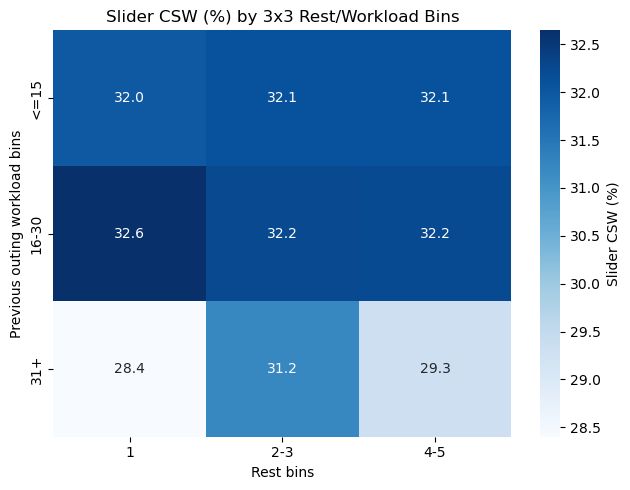

Slider CSW 3x3 summary


,workload_bin_3,rest_bin_3,whiffs,called_strikes,total_slider_pitches,csw_rate_pct
6,16-30,1,1441,1341,8522,32.64
0,16-30,2-3,5335,4847,31591,32.23
2,16-30,4-5,2078,1958,12524,32.23
8,31+,1,17,31,169,28.40
1,31+,2-3,587,609,3829,31.24
7,31+,4-5,464,477,3209,29.32
4,<=15,1,2353,1975,13536,31.97
3,<=15,2-3,5503,4698,31773,32.11
5,<=15,4-5,1948,1696,11348,32.11


In [158]:
# Slider CSW% in 3x3 bins (robust to missing zone columns)
whiff_results = [
    "swinging_strike", "swinging_strike_blocked", "missed_bunt"
 ]

# Reuse 3x3 outing bins if available; otherwise build them
if "three_bin_outings" not in globals():
    three_bin_outings = (
        relievers
        .group_by(["pitcher_id", "date", "game_id"])
.agg([
            pl.len().alias("pitch_count"),
            pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
        ])
        .sort(["pitcher_id", "date", "game_id"])
.with_columns([
            pl.col("pitch_count").shift(1).over("pitcher_id").alias("prev_pitch_count")
        ])
        .filter(
            pl.col("rest_days").is_between(1, 5)
            & pl.col("prev_pitch_count").is_not_null()
        )
        .with_columns([
            pl.when(pl.col("prev_pitch_count") <= 15).then(pl.lit("<=15"))
            .when(pl.col("prev_pitch_count") <= 30).then(pl.lit("16-30"))
            .otherwise(pl.lit("31+"))
            .alias("workload_bin_3"),
            pl.when(pl.col("rest_days") == 1).then(pl.lit("1"))
            .when(pl.col("rest_days") <= 3).then(pl.lit("2-3"))
            .otherwise(pl.lit("4-5"))
            .alias("rest_bin_3")
        ])
    )

slider_3x3 = relievers.join(
    three_bin_outings.select([
        "pitcher_id", "date", "game_id", "workload_bin_3", "rest_bin_3"
    ]),
    on=["pitcher_id", "date", "game_id"],
    how="inner"
).filter(pl.col("pitch_type_abbr") == "SL")

slider_csw_3x3 = (
    slider_3x3
    .with_columns([
        pl.col("pitch_result").is_in(whiff_results).fill_null(False).cast(pl.Int8).alias("is_whiff"),
        (pl.col("pitch_result") == "called_strike").fill_null(False).cast(pl.Int8).alias("is_called_strike")
    ])
    .group_by(["workload_bin_3", "rest_bin_3"])
.agg([
        pl.sum("is_whiff").alias("whiffs"),
        pl.sum("is_called_strike").alias("called_strikes"),
        pl.len().alias("total_slider_pitches")
    ])
    .filter(pl.col("total_slider_pitches") >= 50)
    .with_columns(
        ((pl.col("whiffs") + pl.col("called_strikes")) / pl.col("total_slider_pitches") * 100).alias("csw_rate_pct")
    )
    .to_pandas()
)

csw_heat_3x3 = slider_csw_3x3.pivot(
    index="workload_bin_3",
    columns="rest_bin_3",
    values="csw_rate_pct"
).reindex(["<=15", "16-30", "31+"])[["1", "2-3", "4-5"]]

plt.figure(figsize=(6.5, 5))
sns.heatmap(
    csw_heat_3x3,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Slider CSW (%)"}
)
plt.title("Slider CSW (%) by 3x3 Rest/Workload Bins")
plt.xlabel("Rest bins")
plt.ylabel("Previous outing workload bins")
plt.tight_layout()
plt.show()

print("Slider CSW 3x3 summary")
display(
    slider_csw_3x3.sort_values(["workload_bin_3", "rest_bin_3"]).round({"csw_rate_pct": 2})
)

### Rolling Workload Version (3 Bins)
This section replaces previous-outing workload with rolling prior 7-day pitch workload, binned into 3 groups:
- Low
- Medium
- High

Heatmaps are shown for Whiff%, Strikeout%, and Slider CSW% across rest bins (`1`, `2-3`, `4-5`).

C:\Users\kh6102sj\AppData\Local\Temp\ipykernel_20348\1852226685.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


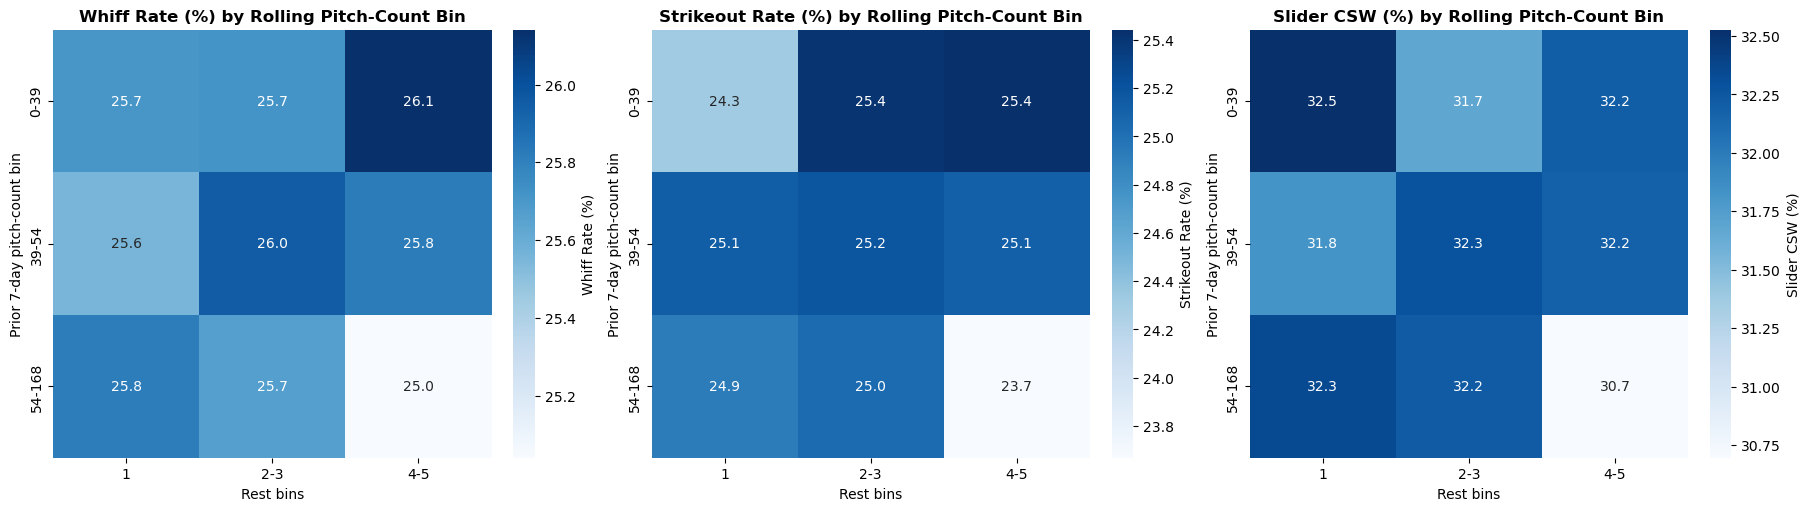

Rolling pitch-count bin ranges (prior 7 days)


,min,max,median
rolling_bin_q,,,
Q1,0.0,39.0,29.0
Q2,39.0,54.0,46.0
Q3,54.0,168.0,64.0


Heatmap separation (higher = clearer visual trend)


,metric,range_pct_points
2,Slider CSW (%),1.83
1,Strikeout Rate (%),1.77
0,Whiff Rate (%),1.10


Recommended primary presentation heatmap: Slider CSW (%)


In [163]:
# Rolling 7-day prior workload -> 3 pitch-count bins, then heatmaps for key outcomes
import numpy as np

# 1) Build outing-level table
rolling_outings = (
    relievers
    .group_by(["pitcher_id", "date", "game_id"])
.agg([
        pl.len().alias("pitch_count"),
        pl.col("pitcher_days_since_prev_game").first().alias("rest_days")
    ])
    .to_pandas()
)
rolling_outings["date"] = pd.to_datetime(rolling_outings["date"])
rolling_outings = rolling_outings.sort_values(["pitcher_id", "date", "game_id"]).reset_index(drop=True)

# 2) Compute rolling prior 7-day pitch workload at day level, then map back to outings
daily_workload = (
    rolling_outings
    .groupby(["pitcher_id", "date"], as_index=False)["pitch_count"]
    .sum()
    .sort_values(["pitcher_id", "date"])
)

def _rolling_7d_prior(g):
    g = g.sort_values("date").set_index("date")
    g["rolling_7d_prev"] = g["pitch_count"].shift(1).rolling("7D", min_periods=1).sum()
    return g.reset_index()

daily_workload = (
    daily_workload
    .groupby("pitcher_id", group_keys=False)
    .apply(_rolling_7d_prior)
    .reset_index(drop=True)
)

rolling_outings = rolling_outings.merge(
    daily_workload[["pitcher_id", "date", "rolling_7d_prev"]],
    on=["pitcher_id", "date"],
    how="left"
)
rolling_outings["rolling_7d_prev"] = rolling_outings["rolling_7d_prev"].fillna(0)

# 3) Define rest bins and 3 rolling workload bins with pitch-count range labels
rolling_outings["rest_bin_3"] = np.select(
    [rolling_outings["rest_days"] == 1, rolling_outings["rest_days"].between(2, 3), rolling_outings["rest_days"].between(4, 5)],
    ["1", "2-3", "4-5"],
    default="other",
)

rank_vals = rolling_outings["rolling_7d_prev"].rank(method="first")
rolling_outings["rolling_bin_q"] = pd.qcut(
    rank_vals,
    q=3,
    labels=["Q1", "Q2", "Q3"]
)

range_by_q = (
    rolling_outings
    .dropna(subset=["rolling_bin_q"])
    .groupby("rolling_bin_q", observed=False)["rolling_7d_prev"]
    .agg(["min", "max", "median"])
)
label_map = {
    q: f"{int(np.floor(row['min']))}-{int(np.ceil(row['max']))}"
    for q, row in range_by_q.iterrows()
}
rolling_outings["rolling_bin_3"] = rolling_outings["rolling_bin_q"].map(label_map)

row_order = [label_map["Q1"], label_map["Q2"], label_map["Q3"]]
col_order = ["1", "2-3", "4-5"]

rolling_outings = rolling_outings[rolling_outings["rest_bin_3"] != "other"].copy()
rolling_outings = rolling_outings.dropna(subset=["rolling_bin_3"]).copy()
rolling_outings["date_key"] = rolling_outings["date"].dt.strftime("%Y-%m-%d")

# 4) Join bins onto pitch-level data in polars
rolling_bin_table = pl.from_pandas(
    rolling_outings[["pitcher_id", "game_id", "date_key", "rest_bin_3", "rolling_bin_3"]]
 )

pitch_roll = (
    relievers
    .with_columns(pl.col("date").cast(pl.Date).cast(pl.Utf8).alias("date_key"))
    .join(rolling_bin_table, on=["pitcher_id", "game_id", "date_key"], how="inner")
)

# 5) Metrics
swing_results = [
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip",
    "foul_bunt", "bunt_foul_tip", "missed_bunt", "hit_into_play"
 ]
whiff_results = ["swinging_strike", "swinging_strike_blocked", "missed_bunt"]
k_results = ["strikeout", "strikeout_double_play"]

# Whiff%
whiff_roll = (
    pitch_roll
    .with_columns([
        pl.col("pitch_result").is_in(swing_results).cast(pl.Int8).alias("is_swing"),
        pl.col("pitch_result").is_in(whiff_results).cast(pl.Int8).alias("is_whiff")
    ])
    .group_by(["rolling_bin_3", "rest_bin_3"])
.agg([
        pl.sum("is_whiff").alias("whiffs"),
        pl.sum("is_swing").alias("swings")
    ])
    .filter(pl.col("swings") > 0)
    .with_columns((pl.col("whiffs") / pl.col("swings") * 100).alias("whiff_rate_pct"))
    .to_pandas()
)

# Strikeout%
k_roll = (
    pitch_roll
    .filter(pl.col("ab_result").is_not_null())
    .with_columns(pl.col("ab_result").is_in(k_results).cast(pl.Int8).alias("is_k"))
    .group_by(["rolling_bin_3", "rest_bin_3"])
.agg([
        pl.len().alias("pa"),
        pl.sum("is_k").alias("ks")
    ])
    .with_columns((pl.col("ks") / pl.col("pa") * 100).alias("k_rate_pct"))
    .to_pandas()
)

# Slider CSW%
slider_roll = pitch_roll.filter(pl.col("pitch_type_abbr") == "SL")
csw_roll = (
    slider_roll
    .with_columns([
        pl.col("pitch_result").is_in(whiff_results).fill_null(False).cast(pl.Int8).alias("is_whiff"),
        (pl.col("pitch_result") == "called_strike").fill_null(False).cast(pl.Int8).alias("is_called_strike")
    ])
    .group_by(["rolling_bin_3", "rest_bin_3"])
.agg([
        pl.sum("is_whiff").alias("whiffs"),
        pl.sum("is_called_strike").alias("called_strikes"),
        pl.len().alias("total_slider_pitches")
    ])
    .filter(pl.col("total_slider_pitches") >= 50)
    .with_columns(((pl.col("whiffs") + pl.col("called_strikes")) / pl.col("total_slider_pitches") * 100).alias("csw_rate_pct"))
    .to_pandas()
)

# 6) Pivot to heatmaps
whiff_heat_roll = (
    whiff_roll.pivot(index="rolling_bin_3", columns="rest_bin_3", values="whiff_rate_pct")
    .reindex(index=row_order, columns=col_order)
)
k_heat_roll = (
    k_roll.pivot(index="rolling_bin_3", columns="rest_bin_3", values="k_rate_pct")
    .reindex(index=row_order, columns=col_order)
)
csw_heat_roll = (
    csw_roll.pivot(index="rolling_bin_3", columns="rest_bin_3", values="csw_rate_pct")
    .reindex(index=row_order, columns=col_order)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

sns.heatmap(whiff_heat_roll, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Whiff Rate (%)"}, ax=axes[0])
axes[0].set_title("Whiff Rate (%) by Rolling Pitch-Count Bin", fontsize=12, weight="bold")
axes[0].set_xlabel("Rest bins")
axes[0].set_ylabel("Prior 7-day pitch-count bin")

sns.heatmap(k_heat_roll, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Strikeout Rate (%)"}, ax=axes[1])
axes[1].set_title("Strikeout Rate (%) by Rolling Pitch-Count Bin", fontsize=12, weight="bold")
axes[1].set_xlabel("Rest bins")
axes[1].set_ylabel("Prior 7-day pitch-count bin")

sns.heatmap(csw_heat_roll, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Slider CSW (%)"}, ax=axes[2])
axes[2].set_title("Slider CSW (%) by Rolling Pitch-Count Bin", fontsize=12, weight="bold")
axes[2].set_xlabel("Rest bins")
axes[2].set_ylabel("Prior 7-day pitch-count bin")

plt.show()

# 7) Recommend best presentation heatmap based on separation (max-min across cells)
spread_df = pd.DataFrame([
    {"metric": "Whiff Rate (%)", "range_pct_points": float(np.nanmax(whiff_heat_roll.values) - np.nanmin(whiff_heat_roll.values))},
    {"metric": "Strikeout Rate (%)", "range_pct_points": float(np.nanmax(k_heat_roll.values) - np.nanmin(k_heat_roll.values))},
    {"metric": "Slider CSW (%)", "range_pct_points": float(np.nanmax(csw_heat_roll.values) - np.nanmin(csw_heat_roll.values))},
]).sort_values("range_pct_points", ascending=False)

best_metric = spread_df.iloc[0]["metric"]

print("Rolling pitch-count bin ranges (prior 7 days)")
display(range_by_q.round(1))

print("Heatmap separation (higher = clearer visual trend)")
display(spread_df.round(2))

print(f"Recommended primary presentation heatmap: {best_metric}")